In [ ]:
!pip install wbgapi

In [ ]:
import wbgapi as wb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
indicators = {
    # === MEVCUT GÖSTERGELER ===
    'SP.DYN.LE00.IN': 'Yasam_Beklentisi',
    'SE.SEC.ENRR': 'Lise_Okullasma_Orani',
    'SH.XPD.CHEX.PC.CD': 'Kisi_Basi_Saglik_Harcamasi',
    'EN.ATM.PM25.MC.M3': 'Hava_Kirliligi_PM25',
    'EN.ATM.CO2E.KT': 'CO2_Emisyonu_KiloTon',
    'SP.POP.TOTL': 'Nufus',
    'SP.DYN.IMRT.IN': 'Bebek_Olum_Orani',
    'SH.DYN.MORT': 'Bes_Yas_Alti_Olum',
    'SH.IMM.HEPB': 'Asi_Hepatit_B',
    'SH.IMM.MEAS': 'Asi_Kizamik',
    'SH.IMM.POL3': 'Asi_Cocuk_Felci',
    'SH.IMM.IDPT': 'Asi_Difteri',
    'SH.DYN.AIDS.ZS': 'HIV_Prevalansi',
    'SH.ALC.PCAP.LI': 'Alkol_Tuketimi',

    # === YENİ: KARBON EMİSYONLARI ===
    'EN.ATM.CO2E.PC':   'CO2_Emisyonu_KisiBasI',      # ton/kişi
    'EN.ATM.METH.KT.CE':'Metan_Emisyonu_KT',           # CO2 eşdeğeri kt
    'EN.ATM.NOXE.KT.CE':'N2O_Emisyonu_KT',             # CO2 eşdeğeri kt
    'EN.ATM.GHGT.KT.CE':'Toplam_Sera_Gazi_KT',         # tüm GHG toplamı

    # === YENİ: ENERJİ & YAKIT ===
    'EG.FEC.RNEW.ZS':   'Yenilenebilir_Enerji_Payi',  # % toplam enerji
    'EG.USE.COMM.FO.ZS':'Fosil_Yakit_Tuketimi',        # % toplam enerji
    'EG.USE.PCAP.KG.OE':'Kisi_Basi_Enerji_Tuketimi',  # kg petrol eşdeğeri
    'EG.ELC.COAL.ZS':   'Komur_Elektrik_Payi',         # % elektrik üretimi
    'EG.ELC.RNWX.ZS':   'Yenilenebilir_Elektrik_Payi',# % elektrik üretimi

    # === YENİ: ORMAN KAYBI / ARAZİ KULLANIMI ===
    'AG.LND.FRST.ZS':   'Orman_Alani_Yuzdesi',         # % kara alanı
    'AG.LND.FRST.K2':   'Orman_Alani_KM2',             # km²
    'AG.LND.AGRI.ZS':   'Tarim_Arazisi_Yuzdesi',       # % kara alanı

    # === YENİ: SU KİRLİLİĞİ ===
    'EE.BOD.TOTL.KG':   'Su_BOD_Emisyonu_KG',          # kg/gün organik kirlilik
    'ER.H2O.FWTL.ZS':   'Tatli_Su_Cekim_Orani',        # % iç kaynaklar
    'SH.H2O.SMDW.ZS':   'Guvenli_Icme_Suyu_Erisimi',   # % nüfus
    'SH.STA.SMSS.ZS':   'Guvenli_Sanitasyon_Erisimi',  # % nüfus
}

print("Genişletilmiş veri seti Dünya Bankası'ndan çekiliyor, lütfen bekleyin...")

# 2. Adım: Veriyi Çekme (2000-2020)
raw_data = wb.data.DataFrame(indicators.keys(), time=range(2000, 2021), numericTimeKeys=True)

# 3. Adım: Veriyi Düzenleme (Geniş formattan Uzun formata)
df_reset = raw_data.reset_index()
df_melted = df_reset.melt(id_vars=['economy', 'series'], var_name='Yil', value_name='Deger')
df_final = df_melted.pivot_table(index=['economy', 'Yil'], columns='series', values='Deger').reset_index()

# Sütun isimlerini Türkçeleştirme
df_final.rename(columns=indicators, inplace=True)
df_final.rename(columns={'economy': 'Ulke_Kodu'}, inplace=True)

# 4. Adım: Ülke Meta Verilerini Çekme (Kıta ve Gelir Durumu)
countries = wb.economy.DataFrame()
meta_data = countries[['name', 'region', 'incomeLevel']].copy()
meta_data.rename(columns={
    'name': 'Ulke_Adi',
    'region': 'Bolge_Kodu',
    'incomeLevel': 'Gelismişlik_Durumu'
}, inplace=True)

# Verileri birleştirme
df_final = df_final.merge(meta_data, left_on='Ulke_Kodu', right_index=True, how='inner')

# 5. Adım: Sadece Avrupa ve Asya'yı Filtreleme
hedef_bolgeler = ['ECS', 'EAS', 'SAS']
df_filtered = df_final[df_final['Bolge_Kodu'].isin(hedef_bolgeler)].copy()

# İsimleri Türkçeleştirme
df_filtered['Kita'] = df_filtered['Bolge_Kodu'].map({
    'ECS': 'Avrupa ve Orta Asya', 'EAS': 'Doğu Asya ve Pasifik', 'SAS': 'Güney Asya'
})

df_filtered['Gelismişlik_Durumu'] = df_filtered['Gelismişlik_Durumu'].map({
    'HIC': 'Yüksek Gelirli (Gelişmiş)', 'UMC': 'Üst-Orta Gelirli',
    'LMC': 'Alt-Orta Gelirli', 'LIC': 'Düşük Gelirli (Gelişmemiş)', 'INX': 'Sınıflandırılmamış'
})

# 6. Adım: Dinamik Sütun Seçimi (Hata Önleyici Sistem)
temel_sutunlar = ['Ulke_Kodu', 'Ulke_Adi', 'Kita', 'Gelismişlik_Durumu', 'Yil']
veri_sutunlari = list(indicators.values())
istenen_sutunlar = temel_sutunlar + veri_sutunlari
mevcut_sutunlar = [col for col in istenen_sutunlar if col in df_filtered.columns]

# Nihai tabloyu oluştur ve sırala
df_analiz = df_filtered[mevcut_sutunlar].sort_values(by=['Ulke_Adi', 'Yil']).reset_index(drop=True)

print("\nVeri hazırlığı başarıyla tamamlandı!")
print(f"Toplam Satır Sayısı: {len(df_analiz)}")
print(f"Toplam Sütun (Değişken) Sayısı: {df_analiz.shape[1]}")
display(df_analiz.head())

Genişletilmiş veri seti Dünya Bankası'ndan çekiliyor, lütfen bekleyin...

Veri hazırlığı başarıyla tamamlandı!
Toplam Satır Sayısı: 2121
Toplam Sütun (Değişken) Sayısı: 28


,Ulke_Kodu,Ulke_Adi,Kita,Gelismişlik_Durumu,Yil,Yasam_Beklentisi,Lise_Okullasma_Orani,Kisi_Basi_Saglik_Harcamasi,Hava_Kirliligi_PM25,Nufus,...,Fosil_Yakit_Tuketimi,Kisi_Basi_Enerji_Tuketimi,Komur_Elektrik_Payi,Yenilenebilir_Elektrik_Payi,Orman_Alani_Yuzdesi,Orman_Alani_KM2,Tarim_Arazisi_Yuzdesi,Tatli_Su_Cekim_Orani,Guvenli_Icme_Suyu_Erisimi,Guvenli_Sanitasyon_Erisimi
0,ALB,Albania,Avrupa ve Orta Asya,Üst-Orta Gelirli,2000,74.826,70.318649,65.476746,22.265189,3089027.0,...,58.626225,581.374749,0.0,0.000000,28.076642,7693.00,41.751825,6.831970,49.138320,22.879987
1,ALB,Albania,Avrupa ve Orta Asya,Üst-Orta Gelirli,2001,75.083,72.484573,73.921715,22.366006,3060173.0,...,60.857697,598.228317,0.0,0.003753,28.123248,7705.77,41.569343,6.507286,49.081199,23.475974
2,ALB,Albania,Avrupa ve Orta Asya,Üst-Orta Gelirli,2002,75.299,74.538918,78.729095,22.482785,3051010.0,...,63.130793,661.117952,0.0,0.007223,28.169854,7718.54,41.605839,6.182602,48.984766,24.036737
3,ALB,Albania,Avrupa ve Orta Asya,Üst-Orta Gelirli,2003,75.557,77.751823,105.436676,22.593449,3039616.0,...,64.410168,649.357881,0.0,0.005409,28.216460,7731.31,40.912409,5.857918,48.885443,24.576771
4,ALB,Albania,Avrupa ve Orta Asya,Üst-Orta Gelirli,2004,75.951,78.980186,136.507248,22.675923,3026939.0,...,65.467668,716.623146,0.0,0.004816,28.263066,7744.08,40.948905,5.533234,50.717678,25.095910


In [ ]:
# Colab'den dosya indirmek için gerekli kütüphane
from google.colab import files

# Veri setini Excel dosyası olarak kaydetme
# index=False komutu, satır numaralarının Excel'e gereksiz bir sütun olarak eklenmesini önler
dosya_adi = 'Dunya_Bankasi_Panel_Verisi.xlsx'
df_analiz.to_excel(dosya_adi, index=False)

print(f"{dosya_adi} oluşturuldu. Bilgisayarınıza indiriliyor...")

# Dosyayı otomatik olarak bilgisayarınıza indirme komutu
files.download(dosya_adi)

Dunya_Bankasi_Panel_Verisi.xlsx oluşturuldu. Bilgisayarınıza indiriliyor...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df_analiz.shape

(2121, 28)

In [ ]:
print(df_analiz.columns.tolist())

['Ulke_Kodu', 'Ulke_Adi', 'Kita', 'Gelismişlik_Durumu', 'Yil', 'Yasam_Beklentisi', 'Lise_Okullasma_Orani', 'Kisi_Basi_Saglik_Harcamasi', 'Hava_Kirliligi_PM25', 'Nufus', 'Bebek_Olum_Orani', 'Bes_Yas_Alti_Olum', 'Asi_Hepatit_B', 'Asi_Kizamik', 'Asi_Difteri', 'HIV_Prevalansi', 'Alkol_Tuketimi', 'Yenilenebilir_Enerji_Payi', 'Fosil_Yakit_Tuketimi', 'Kisi_Basi_Enerji_Tuketimi', 'Komur_Elektrik_Payi', 'Yenilenebilir_Elektrik_Payi', 'Orman_Alani_Yuzdesi', 'Orman_Alani_KM2', 'Tarim_Arazisi_Yuzdesi', 'Tatli_Su_Cekim_Orani', 'Guvenli_Icme_Suyu_Erisimi', 'Guvenli_Sanitasyon_Erisimi']


In [ ]:
df_analiz.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2121 entries, 0 to 2120
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Ulke_Kodu                    2121 non-null   object 
 1   Ulke_Adi                     2121 non-null   object 
 2   Kita                         2121 non-null   object 
 3   Gelismişlik_Durumu           2121 non-null   object 
 4   Yil                          2121 non-null   int64  
 5   Yasam_Beklentisi             2121 non-null   float64
 6   Lise_Okullasma_Orani         1459 non-null   float64
 7   Kisi_Basi_Saglik_Harcamasi   1800 non-null   float64
 8   Hava_Kirliligi_PM25          1911 non-null   float64
 9   Nufus                        2121 non-null   float64
 10  Bebek_Olum_Orani             1848 non-null   float64
 11  Bes_Yas_Alti_Olum            1848 non-null   float64
 12  Asi_Hepatit_B                1535 non-null   float64
 13  Asi_Kizamik       

In [ ]:
eksik_veriler = df_analiz.isnull().sum()
print("Eksik Veri Sayıları:")
print(eksik_veriler[eksik_veriler > 0])

eksik_yuzde = (df_analiz.isnull().sum() / len(df_analiz)) * 100
print("\nEksik Veri Yüzdesi (%):")
print(eksik_yuzde[eksik_yuzde > 0])

Eksik Veri Sayıları:
Lise_Okullasma_Orani           662
Kisi_Basi_Saglik_Harcamasi     321
Hava_Kirliligi_PM25            210
Bebek_Olum_Orani               273
Bes_Yas_Alti_Olum              273
Asi_Hepatit_B                  586
Asi_Kizamik                    302
Asi_Difteri                    302
HIV_Prevalansi                 929
Alkol_Tuketimi                 414
Yenilenebilir_Enerji_Payi       93
Fosil_Yakit_Tuketimi           636
Kisi_Basi_Enerji_Tuketimi      580
Komur_Elektrik_Payi            159
Yenilenebilir_Elektrik_Payi    159
Orman_Alani_Yuzdesi             75
Orman_Alani_KM2                 75
Tarim_Arazisi_Yuzdesi           96
Tatli_Su_Cekim_Orani           642
Guvenli_Icme_Suyu_Erisimi      337
Guvenli_Sanitasyon_Erisimi     531
dtype: int64

Eksik Veri Yüzdesi (%):
Lise_Okullasma_Orani           31.211693
Kisi_Basi_Saglik_Harcamasi     15.134371
Hava_Kirliligi_PM25             9.900990
Bebek_Olum_Orani               12.871287
Bes_Yas_Alti_Olum              12.871287
A

In [ ]:
istatistikler = df_analiz.describe().T
display(istatistikler)

,count,mean,std,min,25%,50%,75%,max
Yil,2121.0,2.010000e+03,6.056729e+00,2000.000000,2005.000000,2.010000e+03,2.015000e+03,2.020000e+03
Yasam_Beklentisi,2121.0,7.449118e+01,6.247036e+00,56.364000,69.680000,7.499200e+01,8.016341e+01,8.615100e+01
Lise_Okullasma_Orani,1459.0,9.383736e+01,2.228913e+01,18.128441,83.888390,9.609331e+01,1.055605e+02,1.640798e+02
Kisi_Basi_Saglik_Harcamasi,1800.0,1.518011e+03,2.078000e+03,4.472150,118.481655,4.675868e+02,2.221105e+03,1.029458e+04
Hava_Kirliligi_PM25,1911.0,1.954761e+01,1.188445e+01,4.895181,11.734457,1.686993e+01,2.361686e+01,7.903740e+01
Nufus,2121.0,4.480038e+07,1.815315e+08,9544.000000,405557.000000,5.052257e+06,1.995152e+07,1.411100e+09
Bebek_Olum_Orani,1848.0,1.534064e+01,1.555273e+01,1.400000,3.800000,8.600000e+00,2.210000e+01,8.580000e+01
Bes_Yas_Alti_Olum,1848.0,1.884242e+01,1.967425e+01,1.500000,4.500000,1.025000e+01,2.682500e+01,1.115000e+02
Asi_Hepatit_B,1535.0,8.786319e+01,1.600186e+01,2.000000,86.000000,9.400000e+01,9.700000e+01,9.900000e+01
Asi_Kizamik,1819.0,9.034305e+01,1.093269e+01,8.000000,87.000000,9.400000e+01,9.700000e+01,9.900000e+01


In [ ]:
print(f"Toplam Ülke Sayısı: {df_analiz['Ulke_Adi'].nunique()}")
print("Ülke İsimleri (İlk 10):")
print(df_analiz['Ulke_Adi'].unique()[:10])

print("\nBenzersiz Kıta/Bölge Listesi:")
print(df_analiz['Kita'].unique())

print("\nGelişmişlik Durumları:")
print(df_analiz['Gelismişlik_Durumu'].unique())

Toplam Ülke Sayısı: 101
Ülke İsimleri (İlk 10):
['Albania' 'American Samoa' 'Andorra' 'Armenia' 'Australia' 'Austria'
 'Azerbaijan' 'Bangladesh' 'Belarus' 'Belgium']

Benzersiz Kıta/Bölge Listesi:
['Avrupa ve Orta Asya' 'Doğu Asya ve Pasifik' 'Güney Asya']

Gelişmişlik Durumları:
['Üst-Orta Gelirli' 'Yüksek Gelirli (Gelişmiş)' 'Alt-Orta Gelirli'
 'Düşük Gelirli (Gelişmemiş)']


In [ ]:
print("Kıta bazlı örnek sayıları:")
display(df_analiz['Kita'].value_counts())

print("\nGelişmişlik durumuna göre örnek sayıları:")
display(df_analiz['Gelismişlik_Durumu'].value_counts())

print("\nÜlke başına düşen örnek sayısı (İlk 5):")
display(df_analiz['Ulke_Adi'].value_counts().head())

Kıta bazlı örnek sayıları:


,count
Kita,
Avrupa ve Orta Asya,1218
Doğu Asya ve Pasifik,777
Güney Asya,126



Gelişmişlik durumuna göre örnek sayıları:


,count
Gelismişlik_Durumu,
Yüksek Gelirli (Gelişmiş),1155
Üst-Orta Gelirli,546
Alt-Orta Gelirli,399
Düşük Gelirli (Gelişmemiş),21



Ülke başına düşen örnek sayısı (İlk 5):


,count
Ulke_Adi,
Albania,21
American Samoa,21
Andorra,21
Armenia,21
Australia,21


In [ ]:
display(df_analiz.sample(5, random_state=42))

,Ulke_Kodu,Ulke_Adi,Kita,Gelismişlik_Durumu,Yil,Yasam_Beklentisi,Lise_Okullasma_Orani,Kisi_Basi_Saglik_Harcamasi,Hava_Kirliligi_PM25,Nufus,...,Fosil_Yakit_Tuketimi,Kisi_Basi_Enerji_Tuketimi,Komur_Elektrik_Payi,Yenilenebilir_Elektrik_Payi,Orman_Alani_Yuzdesi,Orman_Alani_KM2,Tarim_Arazisi_Yuzdesi,Tatli_Su_Cekim_Orani,Guvenli_Icme_Suyu_Erisimi,Guvenli_Sanitasyon_Erisimi
1845,SWE,Sweden,Avrupa ve Orta Asya,Yüksek Gelirli (Gelişmiş),2018,82.558537,140.821747,6042.135254,6.290862,10175214.0,...,0.000000,4966.261118,0.860465,17.713035,68.694498,279800.00,7.366343,1.426784,99.685541,95.294453
1486,NOR,Norway,Avrupa ve Orta Asya,Yüksek Gelirli (Gelişmiş),2016,82.407317,116.611267,7492.076660,6.230592,5234519.0,...,0.000000,5368.576472,0.097959,1.592075,33.271100,121488.00,2.693886,0.693165,99.286310,77.472578
289,BGR,Bulgaria,Avrupa ve Orta Asya,Yüksek Gelirli (Gelişmiş),2016,74.812195,103.003922,579.767151,19.979167,6894139.0,...,0.000000,2606.610534,42.765962,6.991762,35.381356,38410.00,46.250921,27.090476,96.866215,67.312862
1607,ROU,Romania,Avrupa ve Orta Asya,Yüksek Gelirli (Gelişmiş),2011,74.409756,100.735901,426.599731,21.363176,20147528.0,...,77.888627,1771.703586,39.865310,2.549609,28.640535,65921.92,60.746405,15.554507,81.922605,61.540753
1857,CHE,Switzerland,Avrupa ve Orta Asya,Yüksek Gelirli (Gelişmiş),2009,82.043902,95.847832,7263.626953,13.322379,7743831.0,...,53.564856,3460.611444,0.000000,1.915015,31.150263,12308.66,38.915451,5.342946,96.700002,97.881977


In [ ]:
yasam_beklentisi_sutunu = df_analiz['Yasam_Beklentisi']

print(yasam_beklentisi_sutunu.head())

0    74.826
1    75.083
2    75.299
3    75.557
4    75.951
Name: Yasam_Beklentisi, dtype: float64


In [ ]:
omur = df_analiz['Yasam_Beklentisi']

print(f"Ortalama (Mean): {omur.mean():.2f}")
print(f"Medyan (Median): {omur.median():.2f}")
print(f"En Düşük (Min):  {omur.min():.2f}")
print(f"En Yüksek (Max): {omur.max():.2f}")

Ortalama (Mean): 74.49
Medyan (Median): 74.99
En Düşük (Min):  56.36
En Yüksek (Max): 86.15


In [ ]:
uzun_omurlu_ulkeler = df_analiz[df_analiz['Yasam_Beklentisi'] > 75]

display(uzun_omurlu_ulkeler.head())

print(f"75 yaş üstü yaşam beklentisine sahip satır sayısı: {len(uzun_omurlu_ulkeler)}")

,Ulke_Kodu,Ulke_Adi,Kita,Gelismişlik_Durumu,Yil,Yasam_Beklentisi,Lise_Okullasma_Orani,Kisi_Basi_Saglik_Harcamasi,Hava_Kirliligi_PM25,Nufus,...,Fosil_Yakit_Tuketimi,Kisi_Basi_Enerji_Tuketimi,Komur_Elektrik_Payi,Yenilenebilir_Elektrik_Payi,Orman_Alani_Yuzdesi,Orman_Alani_KM2,Tarim_Arazisi_Yuzdesi,Tatli_Su_Cekim_Orani,Guvenli_Icme_Suyu_Erisimi,Guvenli_Sanitasyon_Erisimi
1,ALB,Albania,Avrupa ve Orta Asya,Üst-Orta Gelirli,2001,75.083,72.484573,73.921715,22.366006,3060173.0,...,60.857697,598.228317,0.0,0.003753,28.123248,7705.77,41.569343,6.507286,49.081199,23.475974
2,ALB,Albania,Avrupa ve Orta Asya,Üst-Orta Gelirli,2002,75.299,74.538918,78.729095,22.482785,3051010.0,...,63.130793,661.117952,0.0,0.007223,28.169854,7718.54,41.605839,6.182602,48.984766,24.036737
3,ALB,Albania,Avrupa ve Orta Asya,Üst-Orta Gelirli,2003,75.557,77.751823,105.436676,22.593449,3039616.0,...,64.410168,649.357881,0.0,0.005409,28.216460,7731.31,40.912409,5.857918,48.885443,24.576771
4,ALB,Albania,Avrupa ve Orta Asya,Üst-Orta Gelirli,2004,75.951,78.980186,136.507248,22.675923,3026939.0,...,65.467668,716.623146,0.0,0.004816,28.263066,7744.08,40.948905,5.533234,50.717678,25.095910
5,ALB,Albania,Avrupa ve Orta Asya,Üst-Orta Gelirli,2005,76.427,82.971428,149.975159,22.708130,3011487.0,...,66.349016,721.077407,0.0,0.004960,28.309672,7756.85,39.306569,5.208550,52.578335,25.871434


75 yaş üstü yaşam beklentisine sahip satır sayısı: 1058


In [ ]:
turkiye_verisi = df_analiz[df_analiz['Ulke_Kodu'] == 'TUR']

display(turkiye_verisi)

,Ulke_Kodu,Ulke_Adi,Kita,Gelismişlik_Durumu,Yil,Yasam_Beklentisi,Lise_Okullasma_Orani,Kisi_Basi_Saglik_Harcamasi,Hava_Kirliligi_PM25,Nufus,...,Fosil_Yakit_Tuketimi,Kisi_Basi_Enerji_Tuketimi,Komur_Elektrik_Payi,Yenilenebilir_Elektrik_Payi,Orman_Alani_Yuzdesi,Orman_Alani_KM2,Tarim_Arazisi_Yuzdesi,Tatli_Su_Cekim_Orani,Guvenli_Icme_Suyu_Erisimi,Guvenli_Sanitasyon_Erisimi
1953,TUR,Turkiye,Avrupa ve Orta Asya,Üst-Orta Gelirli,2000,71.931,74.587990,192.834457,22.497297,65425961.0,...,85.874121,1166.014120,30.568675,0.220257,26.179268,201483.50,52.595403,18.502203,NaN,44.231676
1954,TUR,Turkiye,Avrupa ve Orta Asya,Üst-Orta Gelirli,2001,72.271,85.313622,148.862106,22.393303,66245128.0,...,86.049076,1060.570720,31.302506,0.274150,26.300720,202418.23,53.230773,18.034875,NaN,44.218587
1955,TUR,Turkiye,Avrupa ve Orta Asya,Üst-Orta Gelirli,2002,72.605,90.110992,181.391449,22.145393,67048795.0,...,86.048896,1107.279910,24.844668,0.219389,26.422172,203352.96,53.527019,17.567548,NaN,44.692676
1956,TUR,Turkiye,Avrupa ve Orta Asya,Üst-Orta Gelirli,2003,72.906,91.822731,232.556244,21.849519,67831730.0,...,86.148874,1159.996658,22.941934,0.163955,26.543624,204287.69,52.809792,17.100220,NaN,45.154922
1957,TUR,Turkiye,Avrupa ve Orta Asya,Üst-Orta Gelirli,2004,73.223,88.313690,292.653076,21.601630,68592617.0,...,86.711217,1176.754302,22.858963,0.152112,26.665075,205222.42,53.545210,17.417658,NaN,46.702234
1958,TUR,Turkiye,Avrupa ve Orta Asya,Üst-Orta Gelirli,2005,73.510,84.943718,357.401978,21.497678,69329557.0,...,88.291502,1211.465616,26.668972,0.117050,26.786527,206157.15,53.562101,17.735095,NaN,48.269754
1959,TUR,Turkiye,Avrupa ve Orta Asya,Üst-Orta Gelirli,2006,73.804,88.552788,409.258820,21.823966,70045349.0,...,89.083816,1328.692301,26.460729,0.159672,26.907979,207091.88,52.613594,18.052533,NaN,49.857449
1960,TUR,Turkiye,Avrupa ve Orta Asya,Üst-Orta Gelirli,2007,74.129,90.734451,504.376465,22.602063,70158112.0,...,90.207898,1429.923006,27.892858,0.318624,27.029431,208026.61,51.329860,18.268557,NaN,51.184864
1961,TUR,Turkiye,Avrupa ve Orta Asya,Üst-Orta Gelirli,2008,74.380,89.056969,561.735291,23.530822,71051678.0,...,90.831255,1385.178015,29.088087,0.583002,27.150883,208961.34,50.832218,18.484581,NaN,52.555047
1962,TUR,Turkiye,Avrupa ve Orta Asya,Üst-Orta Gelirli,2009,74.679,80.190742,492.300323,24.309094,72039206.0,...,89.460637,1364.097304,28.583455,1.124397,27.272335,209896.07,50.558060,19.881057,NaN,53.968105


In [ ]:
kita_omur = df_analiz.groupby('Kita')['Yasam_Beklentisi'].mean().sort_values(ascending=False)
print(kita_omur)

Kita
Avrupa ve Orta Asya     76.674276
Doğu Asya ve Pasifik    71.803415
Güney Asya              69.962421
Name: Yasam_Beklentisi, dtype: float64


In [ ]:
sirali_df = df_analiz.sort_values(by='Yasam_Beklentisi')
display(sirali_df.head())

,Ulke_Kodu,Ulke_Adi,Kita,Gelismişlik_Durumu,Yil,Yasam_Beklentisi,Lise_Okullasma_Orani,Kisi_Basi_Saglik_Harcamasi,Hava_Kirliligi_PM25,Nufus,...,Fosil_Yakit_Tuketimi,Kisi_Basi_Enerji_Tuketimi,Komur_Elektrik_Payi,Yenilenebilir_Elektrik_Payi,Orman_Alani_Yuzdesi,Orman_Alani_KM2,Tarim_Arazisi_Yuzdesi,Tatli_Su_Cekim_Orani,Guvenli_Icme_Suyu_Erisimi,Guvenli_Sanitasyon_Erisimi
1310,MMR,Myanmar,Doğu Asya ve Pasifik,Alt-Orta Gelirli,2008,56.364,49.979012,14.708179,38.207124,48390793.0,...,27.230143,326.247586,9.004253,2.966124,49.174851,321264.22,18.791998,3.313821,40.131537,61.055669
1911,TLS,Timor-Leste,Doğu Asya ve Pasifik,Alt-Orta Gelirli,2000,58.097,NaN,NaN,21.062674,745088.0,...,NaN,NaN,NaN,NaN,63.826496,9491.00,22.663080,NaN,NaN,NaN
1008,LAO,Lao PDR,Doğu Asya ve Pasifik,Alt-Orta Gelirli,2000,58.317,33.267071,14.103139,28.820009,5431212.0,...,0.000000,296.828433,0.000000,7.303665,75.498267,174250.00,7.824957,NaN,5.142677,21.150605
1912,TLS,Timor-Leste,Doğu Asya ve Pasifik,Alt-Orta Gelirli,2001,58.772,41.320690,NaN,21.003565,812249.0,...,NaN,NaN,NaN,NaN,63.732347,9477.00,22.636180,NaN,NaN,NaN
1009,LAO,Lao PDR,Doğu Asya ve Pasifik,Alt-Orta Gelirli,2001,58.887,35.189651,14.466650,28.827411,5521482.0,...,0.000000,305.203788,0.000000,-0.344828,75.288345,173765.50,7.976603,NaN,6.732693,23.703032


In [ ]:
en_yuksek_harcama = df_analiz.sort_values(by='Kisi_Basi_Saglik_Harcamasi', ascending=False)
display(en_yuksek_harcama.head(10))

,Ulke_Kodu,Ulke_Adi,Kita,Gelismişlik_Durumu,Yil,Yasam_Beklentisi,Lise_Okullasma_Orani,Kisi_Basi_Saglik_Harcamasi,Hava_Kirliligi_PM25,Nufus,...,Fosil_Yakit_Tuketimi,Kisi_Basi_Enerji_Tuketimi,Komur_Elektrik_Payi,Yenilenebilir_Elektrik_Payi,Orman_Alani_Yuzdesi,Orman_Alani_KM2,Tarim_Arazisi_Yuzdesi,Tatli_Su_Cekim_Orani,Guvenli_Icme_Suyu_Erisimi,Guvenli_Sanitasyon_Erisimi
1868,CHE,Switzerland,Avrupa ve Orta Asya,Yüksek Gelirli (Gelişmiş),2020,83.000000,104.211617,10294.578125,9.061050,8638167.0,...,0.0,2690.390233,0.0,6.588678,32.121536,12691.100,38.027106,4.217822,96.700000,99.625324
1064,LIE,Liechtenstein,Avrupa ve Orta Asya,Yüksek Gelirli (Gelişmiş),2014,82.073171,115.557831,10096.853516,NaN,37248.0,...,NaN,NaN,NaN,NaN,41.873750,66.998,32.750000,NaN,100.000000,96.182610
1070,LIE,Liechtenstein,Avrupa ve Orta Asya,Yüksek Gelirli (Gelişmiş),2020,81.658537,120.228447,10004.528320,NaN,38901.0,...,NaN,NaN,NaN,NaN,41.875000,67.000,32.312500,NaN,100.000000,96.261441
1063,LIE,Liechtenstein,Avrupa ve Orta Asya,Yüksek Gelirli (Gelişmiş),2013,82.260976,NaN,9956.297852,NaN,36984.0,...,NaN,NaN,NaN,NaN,41.873125,66.997,33.375000,NaN,100.000000,96.169472
1068,LIE,Liechtenstein,Avrupa ve Orta Asya,Yüksek Gelirli (Gelişmiş),2018,83.041463,112.010162,9736.243164,NaN,38246.0,...,NaN,NaN,NaN,NaN,41.875000,67.000,32.375000,NaN,100.000000,96.235164
1067,LIE,Liechtenstein,Avrupa ve Orta Asya,Yüksek Gelirli (Gelişmiş),2017,83.746341,117.094330,9715.075195,NaN,37962.0,...,NaN,NaN,NaN,NaN,41.875000,67.000,32.375000,NaN,100.000000,96.222026
1066,LIE,Liechtenstein,Avrupa ve Orta Asya,Yüksek Gelirli (Gelişmiş),2016,82.258537,116.028374,9703.758789,NaN,37716.0,...,NaN,NaN,NaN,NaN,41.875000,67.000,32.500000,NaN,100.000000,96.208887
1069,LIE,Liechtenstein,Avrupa ve Orta Asya,Yüksek Gelirli (Gelişmiş),2019,84.160976,119.209663,9686.883789,NaN,38563.0,...,NaN,NaN,NaN,NaN,41.875000,67.000,32.312500,NaN,100.000000,96.248302
1065,LIE,Liechtenstein,Avrupa ve Orta Asya,Yüksek Gelirli (Gelişmiş),2015,82.656098,116.123444,9639.751953,NaN,37494.0,...,NaN,NaN,NaN,NaN,41.875000,67.000,32.625000,NaN,100.000000,96.195749
1867,CHE,Switzerland,Avrupa ve Orta Asya,Yüksek Gelirli (Gelişmiş),2019,83.904878,104.071114,9609.802734,9.450019,8575280.0,...,0.0,2857.158192,0.0,5.713275,32.034469,12656.700,38.105034,4.217822,96.699999,99.451126


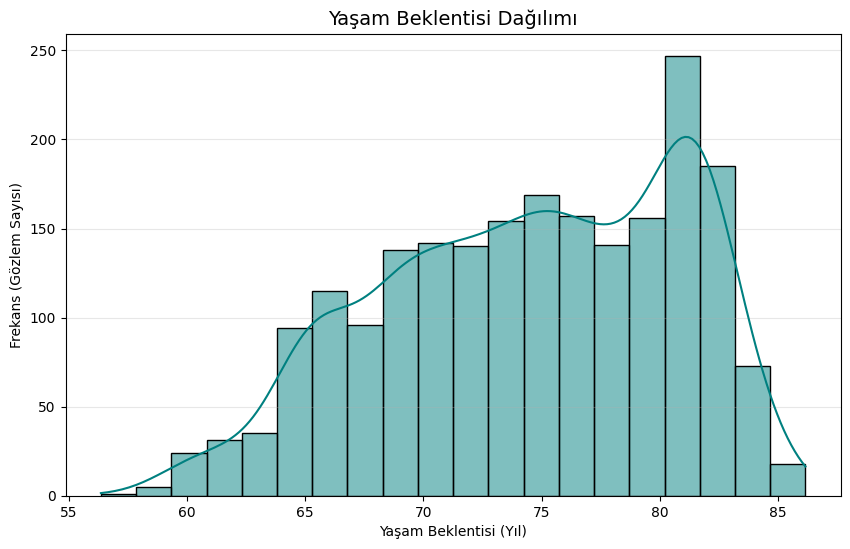

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_analiz['Yasam_Beklentisi'], bins=20, kde=True, color='teal')

plt.title('Yaşam Beklentisi Dağılımı', fontsize=14)
plt.xlabel('Yaşam Beklentisi (Yıl)')
plt.ylabel('Frekans (Gözlem Sayısı)')
plt.grid(axis='y', alpha=0.3)

plt.show()

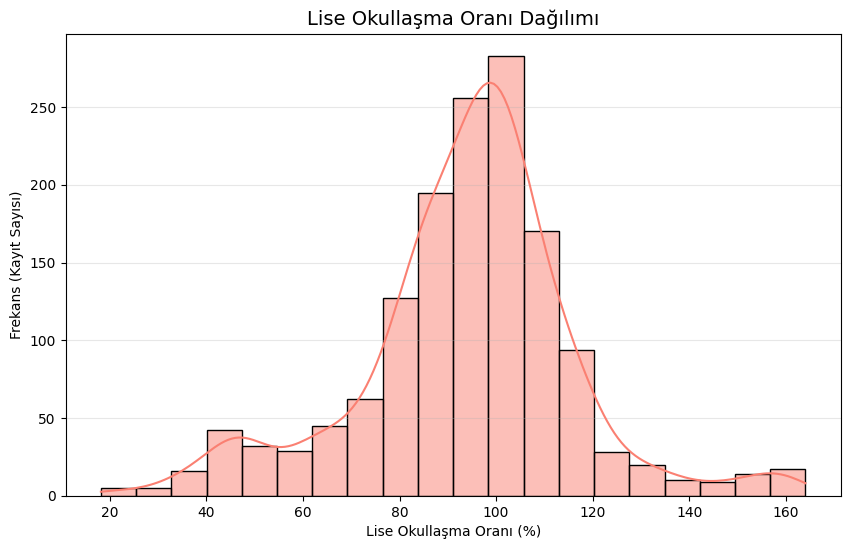

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_analiz['Lise_Okullasma_Orani'], bins=20, kde=True, color='salmon')

plt.title('Lise Okullaşma Oranı Dağılımı', fontsize=14)
plt.xlabel('Lise Okullaşma Oranı (%)')
plt.ylabel('Frekans (Kayıt Sayısı)')
plt.grid(axis='y', alpha=0.3)

plt.show()

/tmp/ipykernel_7133/46530537.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_analiz, y='Kita', order=order_kita, palette='viridis')


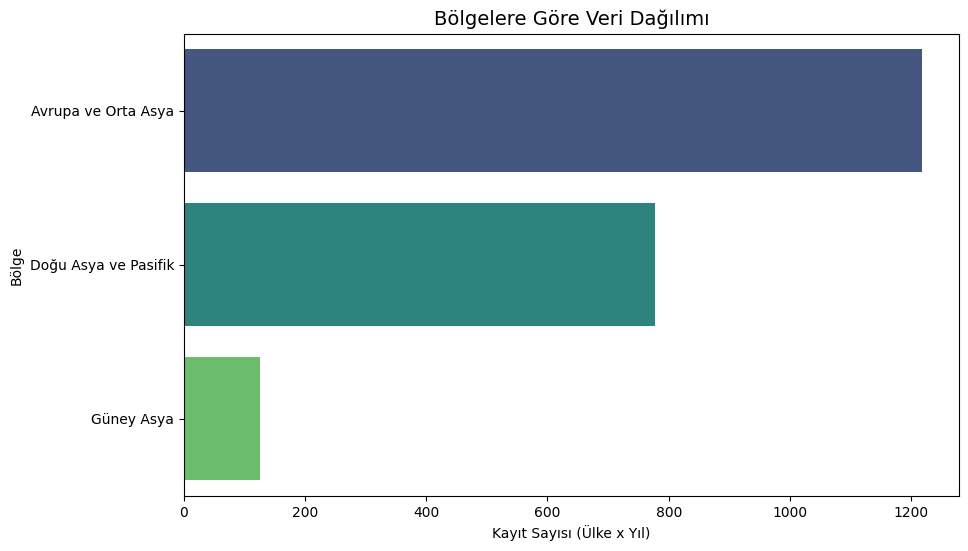

/tmp/ipykernel_7133/46530537.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_analiz, x='Gelismişlik_Durumu', order=order_gelisim, palette='flare')


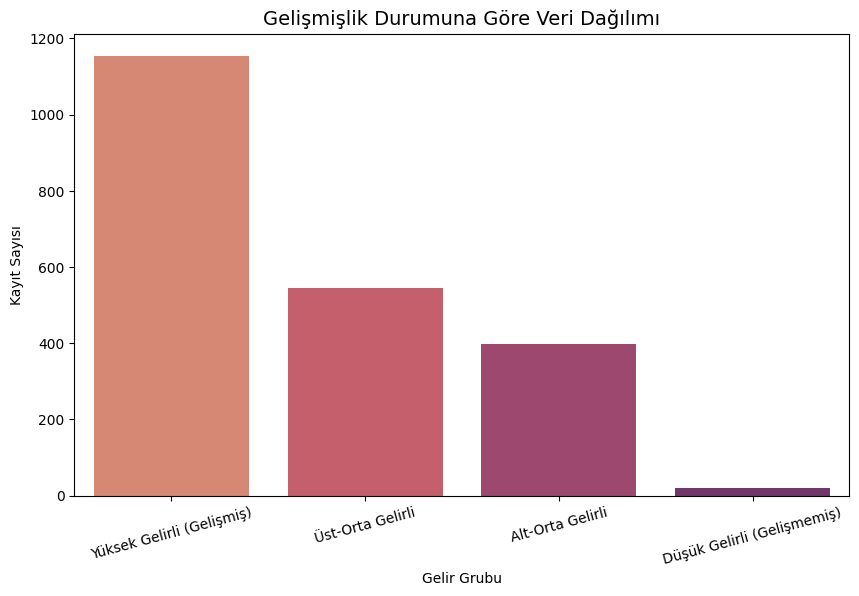

In [ ]:
plt.figure(figsize=(10, 6))
order_kita = df_analiz['Kita'].value_counts().index
sns.countplot(data=df_analiz, y='Kita', order=order_kita, palette='viridis')

plt.title('Bölgelere Göre Veri Dağılımı', fontsize=14)
plt.xlabel('Kayıt Sayısı (Ülke x Yıl)')
plt.ylabel('Bölge')
plt.show()

plt.figure(figsize=(10, 6))
order_gelisim = df_analiz['Gelismişlik_Durumu'].value_counts().index
sns.countplot(data=df_analiz, x='Gelismişlik_Durumu', order=order_gelisim, palette='flare')

plt.title('Gelişmişlik Durumuna Göre Veri Dağılımı', fontsize=14)
plt.xlabel('Gelir Grubu')
plt.ylabel('Kayıt Sayısı')
plt.xticks(rotation=15)
plt.show()

/tmp/ipykernel_7133/892280168.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_analiz, x='Kita', y='Yasam_Beklentisi', palette='Set2')


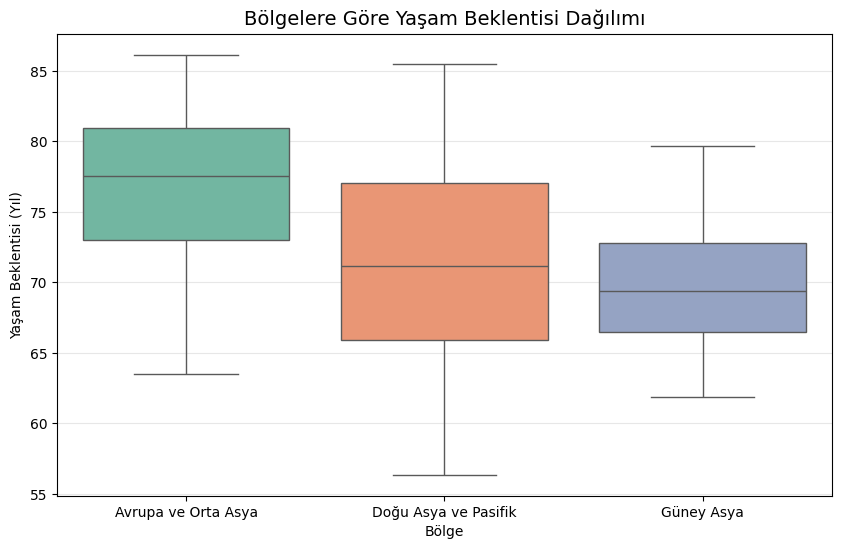

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_analiz, x='Kita', y='Yasam_Beklentisi', palette='Set2')

plt.title('Bölgelere Göre Yaşam Beklentisi Dağılımı', fontsize=14)
plt.xlabel('Bölge')
plt.ylabel('Yaşam Beklentisi (Yıl)')
plt.grid(axis='y', alpha=0.3)
plt.show()

/tmp/ipykernel_7133/1842435360.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_analiz, x='Kita', y='Lise_Okullasma_Orani', palette='Pastel1')


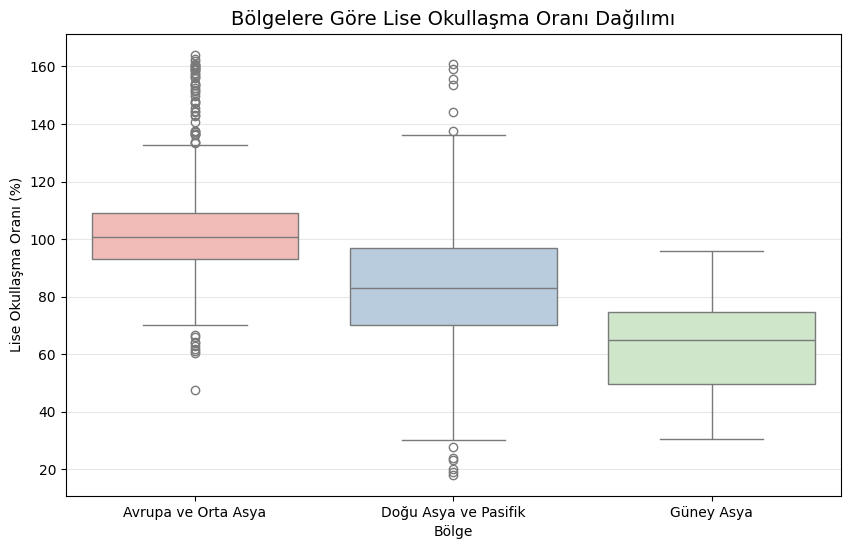

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_analiz, x='Kita', y='Lise_Okullasma_Orani', palette='Pastel1')

plt.title('Bölgelere Göre Lise Okullaşma Oranı Dağılımı', fontsize=14)
plt.xlabel('Bölge')
plt.ylabel('Lise Okullaşma Oranı (%)')
plt.grid(axis='y', alpha=0.3)
plt.show()

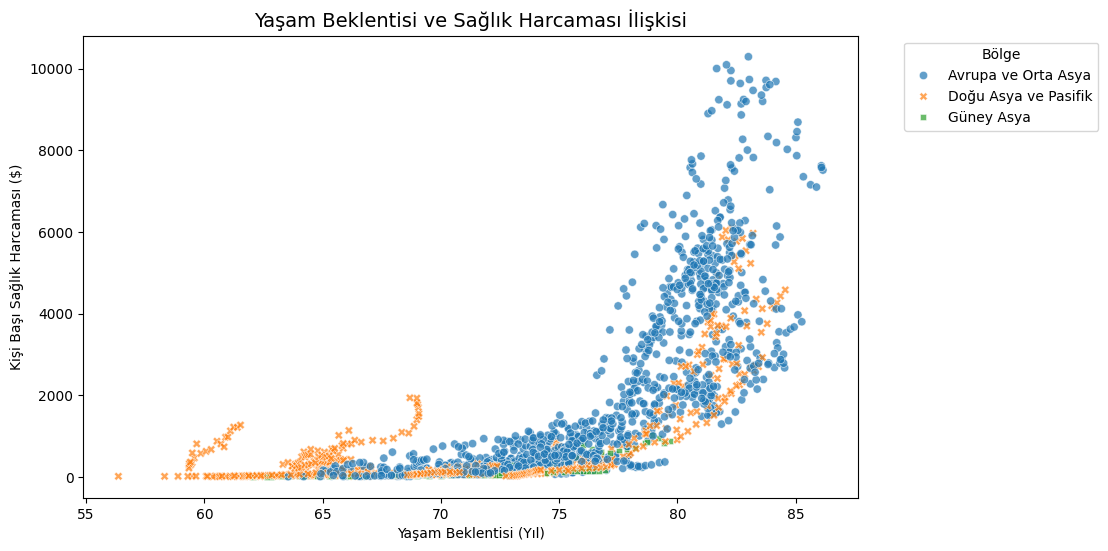

In [ ]:
plt.rcParams['figure.figsize'] = (10, 6)
sns.scatterplot(
    data=df_analiz,
    x='Yasam_Beklentisi',
    y='Kisi_Basi_Saglik_Harcamasi',
    hue='Kita',        # Noktaları bölgeye göre renklendirir
    style='Kita',      # Noktaları bölgeye göre farklı şekillerle gösterir
    alpha=0.7          # Noktaların şeffaflığı (üst üste binmeleri görmek için)
)

plt.title('Yaşam Beklentisi ve Sağlık Harcaması İlişkisi', fontsize=14)
plt.xlabel('Yaşam Beklentisi (Yıl)')
plt.ylabel('Kişi Başı Sağlık Harcaması ($)')
plt.legend(title='Bölge', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

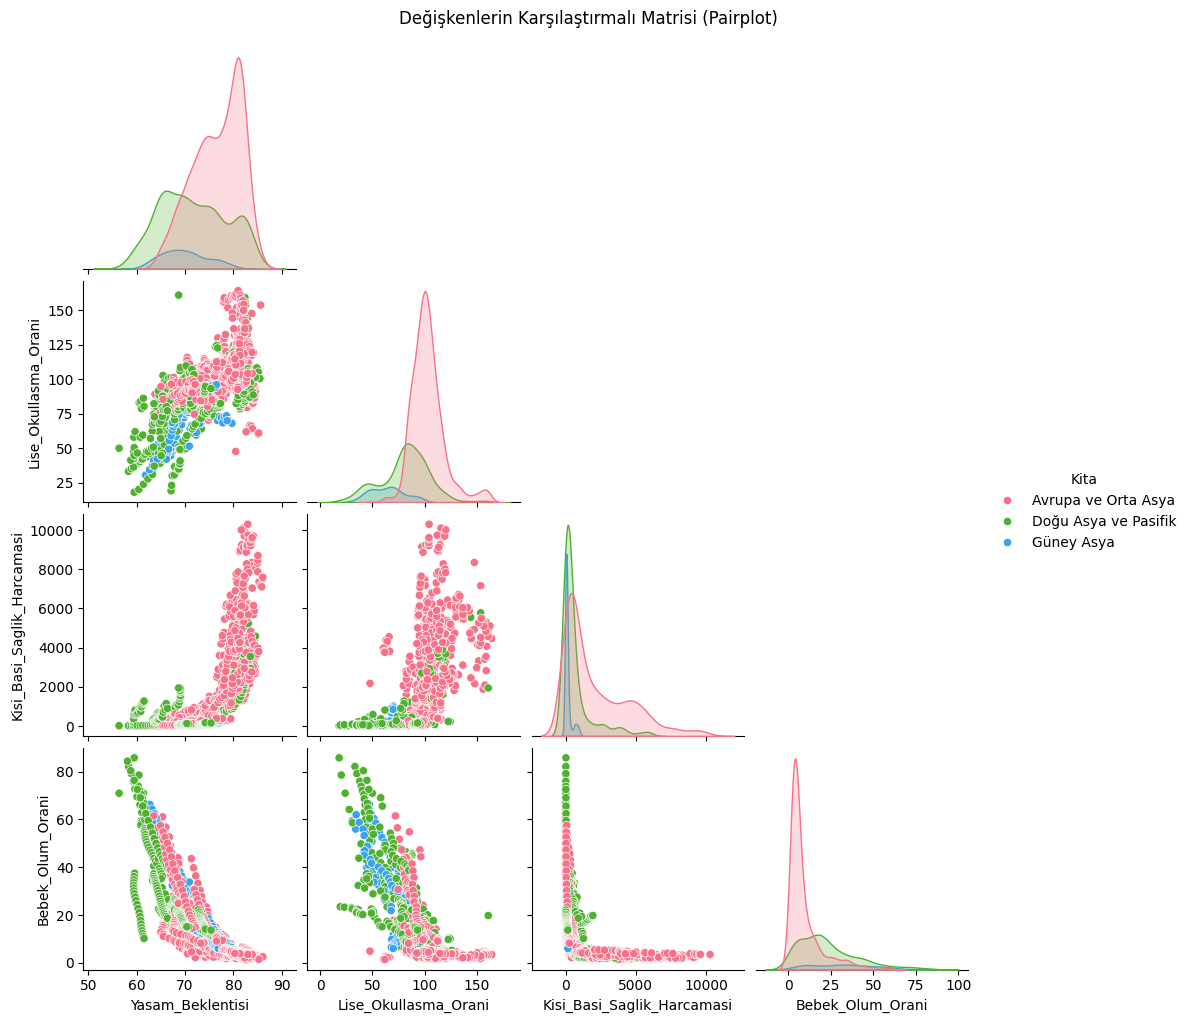

In [ ]:
secili_sutunlar = ['Yasam_Beklentisi', 'Lise_Okullasma_Orani',
                   'Kisi_Basi_Saglik_Harcamasi', 'Bebek_Olum_Orani', 'Kita']

sns.pairplot(df_analiz[secili_sutunlar], hue='Kita', palette='husl', corner=True)

plt.suptitle('Değişkenlerin Karşılaştırmalı Matrisi (Pairplot)', y=1.02)
plt.show()

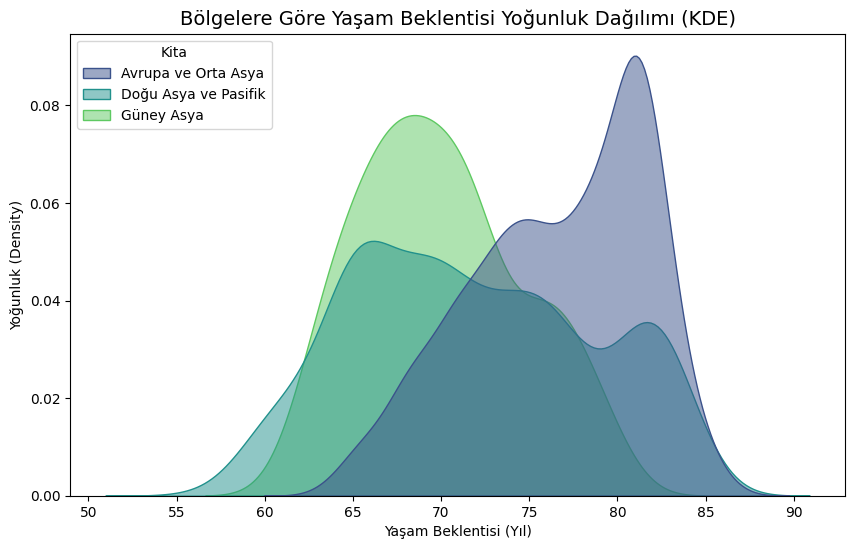

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df_analiz,
    x='Yasam_Beklentisi',
    hue='Kita',
    fill=True,
    common_norm=False,
    palette='viridis',
    alpha=0.5
)

plt.title('Bölgelere Göre Yaşam Beklentisi Yoğunluk Dağılımı (KDE)', fontsize=14)
plt.xlabel('Yaşam Beklentisi (Yıl)')
plt.ylabel('Yoğunluk (Density)')
plt.show()

In [ ]:
df_analiz['Toplam_Saglik_Harcamasi'] = df_analiz['Nufus'] * df_analiz['Kisi_Basi_Saglik_Harcamasi']
display(df_analiz[['Ulke_Adi', 'Nufus', 'Kisi_Basi_Saglik_Harcamasi', 'Toplam_Saglik_Harcamasi']].head())

,Ulke_Adi,Nufus,Kisi_Basi_Saglik_Harcamasi,Toplam_Saglik_Harcamasi
0,Albania,3089027.0,65.476746,2.022594e+08
1,Albania,3060173.0,73.921715,2.262132e+08
2,Albania,3051010.0,78.729095,2.402033e+08
3,Albania,3039616.0,105.436676,3.204870e+08
4,Albania,3026939.0,136.507248,4.131991e+08


In [ ]:
co2_col = [col for col in df_analiz.columns if 'CO2' in col]
nufus_col = [col for col in df_analiz.columns if 'Nufus' in col or 'nufus' in col.lower()]

print("CO2 sütunları:", co2_col)
print("Nüfus sütunları:", nufus_col)
print("df_analiz sütunları:")
for col in df_analiz.columns:
    print(f"  '{col}'")

CO2 sütunları: []
Nüfus sütunları: ['Nufus']
df_analiz sütunları:
  'Ulke_Kodu'
  'Ulke_Adi'
  'Kita'
  'Gelismişlik_Durumu'
  'Yil'
  'Yasam_Beklentisi'
  'Lise_Okullasma_Orani'
  'Kisi_Basi_Saglik_Harcamasi'
  'Hava_Kirliligi_PM25'
  'Nufus'
  'Bebek_Olum_Orani'
  'Bes_Yas_Alti_Olum'
  'Asi_Hepatit_B'
  'Asi_Kizamik'
  'Asi_Difteri'
  'HIV_Prevalansi'
  'Alkol_Tuketimi'
  'Yenilenebilir_Enerji_Payi'
  'Fosil_Yakit_Tuketimi'
  'Kisi_Basi_Enerji_Tuketimi'
  'Komur_Elektrik_Payi'
  'Yenilenebilir_Elektrik_Payi'
  'Orman_Alani_Yuzdesi'
  'Orman_Alani_KM2'
  'Tarim_Arazisi_Yuzdesi'
  'Tatli_Su_Cekim_Orani'
  'Guvenli_Icme_Suyu_Erisimi'
  'Guvenli_Sanitasyon_Erisimi'
  'Toplam_Saglik_Harcamasi'


Kirlilik Endeksi hesaplandı. Dolu satır: 1357

En kirli 10 ülke-yıl:
    Ulke_Adi   Yil  Kirlilik_Endeksi
770    India  2014          0.781707
769    India  2013          0.762605
768    India  2012          0.750472
349    China  2013          0.732262
771    India  2015          0.713877
347    China  2011          0.706876
350    China  2014          0.706785
342    China  2006          0.697972
343    China  2007          0.697356
341    China  2005          0.695471

En temiz 10 ülke-yıl:
       Ulke_Adi   Yil  Kirlilik_Endeksi
1086  Lithuania  2015          0.098601
755     Iceland  2020          0.105294
751     Iceland  2016          0.108294
754     Iceland  2019          0.108384
753     Iceland  2018          0.109079
752     Iceland  2017          0.111061
749     Iceland  2014          0.131219
750     Iceland  2015          0.131702
747     Iceland  2012          0.131735
748     Iceland  2013          0.132120


/tmp/ipykernel_7133/4139123822.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_analiz.dropna(subset=['Kirlilik_Endeksi']),


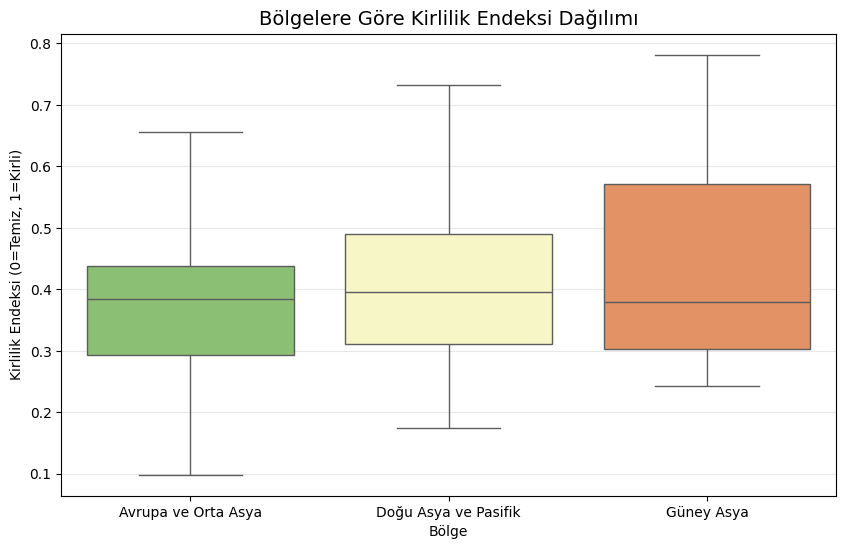

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Kirlilik yönünde çalışan göstergeler
# Yüksek = daha kirli: PM25, Fosil_Yakit, Komur_Elektrik, Tatli_Su_Cekim
# Düşük = daha kirli (ters): Yenilenebilir_Enerji

kirlilik_df = df_analiz[[
    'Ulke_Kodu', 'Ulke_Adi', 'Kita', 'Gelismişlik_Durumu', 'Yil',
    'Hava_Kirliligi_PM25',
    'Fosil_Yakit_Tuketimi',
    'Komur_Elektrik_Payi',
    'Tatli_Su_Cekim_Orani',
    'Yenilenebilir_Enerji_Payi'
]].dropna().copy()

scaler = MinMaxScaler()

# Kirlilik yönünde normalize et (0=temiz, 1=kirli)
kirlilik_df['PM25_norm']        = scaler.fit_transform(kirlilik_df[['Hava_Kirliligi_PM25']])
kirlilik_df['Fosil_norm']       = scaler.fit_transform(kirlilik_df[['Fosil_Yakit_Tuketimi']])
kirlilik_df['Komur_norm']       = scaler.fit_transform(kirlilik_df[['Komur_Elektrik_Payi']])
kirlilik_df['Su_norm']          = scaler.fit_transform(kirlilik_df[['Tatli_Su_Cekim_Orani']])
kirlilik_df['Yenilenebilir_norm'] = 1 - scaler.fit_transform(kirlilik_df[['Yenilenebilir_Enerji_Payi']])  # ters

# Ağırlıklı ortalama (PM25 en güvenilir, daha yüksek ağırlık)
kirlilik_df['Kirlilik_Endeksi'] = (
    kirlilik_df['PM25_norm']          * 0.35 +
    kirlilik_df['Fosil_norm']         * 0.25 +
    kirlilik_df['Komur_norm']         * 0.20 +
    kirlilik_df['Su_norm']            * 0.10 +
    kirlilik_df['Yenilenebilir_norm'] * 0.10
)

# Sonuçları df_analiz'e geri ekle
df_analiz = df_analiz.merge(
    kirlilik_df[['Ulke_Kodu', 'Yil', 'Kirlilik_Endeksi']],
    on=['Ulke_Kodu', 'Yil'], how='left'
)

print(f"Kirlilik Endeksi hesaplandı. Dolu satır: {df_analiz['Kirlilik_Endeksi'].notna().sum()}")
print(f"\nEn kirli 10 ülke-yıl:")
print(df_analiz[['Ulke_Adi', 'Yil', 'Kirlilik_Endeksi']]
      .dropna()
      .sort_values('Kirlilik_Endeksi', ascending=False)
      .head(10))

print(f"\nEn temiz 10 ülke-yıl:")
print(df_analiz[['Ulke_Adi', 'Yil', 'Kirlilik_Endeksi']]
      .dropna()
      .sort_values('Kirlilik_Endeksi')
      .head(10))

# Görselleştirme
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_analiz.dropna(subset=['Kirlilik_Endeksi']),
            x='Kita', y='Kirlilik_Endeksi', palette='RdYlGn_r')
plt.title('Bölgelere Göre Kirlilik Endeksi Dağılımı', fontsize=14)
plt.xlabel('Bölge')
plt.ylabel('Kirlilik Endeksi (0=Temiz, 1=Kirli)')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [ ]:
df_analiz[df_analiz['Ulke_Kodu'] == 'TUR'][['Yil', 'Kirlilik_Endeksi']].dropna()

,Yil,Kirlilik_Endeksi
1953,2000,0.456187
1954,2001,0.456581
1955,2002,0.442735
1956,2003,0.438864
1957,2004,0.437862
1958,2005,0.449330
1959,2006,0.452889
1960,2007,0.463128
1961,2008,0.470952
1962,2009,0.470873


In [ ]:
# Tüm sayısal sütunları belirle (kategorik olanları dışla)
kategorik_sutunlar = ['Ulke_Kodu', 'Ulke_Adi', 'Kita', 'Gelismişlik_Durumu', 'Yil']
sayisal_sutunlar = [col for col in df_analiz.columns if col not in kategorik_sutunlar]

print("Imputation öncesi eksik veri sayıları:")
print(df_analiz[sayisal_sutunlar].isnull().sum()[df_analiz[sayisal_sutunlar].isnull().sum() > 0])

# Kıta + Gelişmişlik Durumu grubunun medyanıyla doldur
def median_impute_group(df, sayisal_cols, grup=['Kita', 'Gelismişlik_Durumu']):
    df_imputed = df.copy()

    for col in sayisal_cols:
        eksik_oncesi = df_imputed[col].isnull().sum()
        if eksik_oncesi == 0:
            continue

        # Grup medyanıyla doldur
        df_imputed[col] = df_imputed.groupby(grup)[col].transform(
            lambda x: x.fillna(x.median())
        )

        # Grup medyanı yeterli olmazsa (grubun tamamı boşsa) genel medyanla doldur
        kalan_eksik = df_imputed[col].isnull().sum()
        if kalan_eksik > 0:
            genel_medyan = df_imputed[col].median()
            df_imputed[col] = df_imputed[col].fillna(genel_medyan)
            print(f"  [{col}] {eksik_oncesi} eksik → grup medyanı sonrası {kalan_eksik} kaldı → genel medyan ({genel_medyan:.2f}) ile kapatıldı")
        else:
            print(f"  [{col}] {eksik_oncesi} eksik → grup medyanıyla tamamen dolduruldu ✓")

    return df_imputed

df_analiz = median_impute_group(df_analiz, sayisal_sutunlar)

# Doğrulama
print("\nImputation sonrası eksik veri kontrolü:")
kalan = df_analiz[sayisal_sutunlar].isnull().sum()
if kalan.sum() == 0:
    print("✓ Hiç eksik veri kalmadı!")
else:
    print(kalan[kalan > 0])

print(f"\nVeri seti boyutu korundu: {df_analiz.shape}")

Imputation öncesi eksik veri sayıları:
Lise_Okullasma_Orani           662
Kisi_Basi_Saglik_Harcamasi     321
Hava_Kirliligi_PM25            210
Bebek_Olum_Orani               273
Bes_Yas_Alti_Olum              273
Asi_Hepatit_B                  586
Asi_Kizamik                    302
Asi_Difteri                    302
HIV_Prevalansi                 929
Alkol_Tuketimi                 414
Yenilenebilir_Enerji_Payi       93
Fosil_Yakit_Tuketimi           636
Kisi_Basi_Enerji_Tuketimi      580
Komur_Elektrik_Payi            159
Yenilenebilir_Elektrik_Payi    159
Orman_Alani_Yuzdesi             75
Orman_Alani_KM2                 75
Tarim_Arazisi_Yuzdesi           96
Tatli_Su_Cekim_Orani           642
Guvenli_Icme_Suyu_Erisimi      337
Guvenli_Sanitasyon_Erisimi     531
Toplam_Saglik_Harcamasi        321
Kirlilik_Endeksi               764
dtype: int64
  [Lise_Okullasma_Orani] 662 eksik → grup medyanıyla tamamen dolduruldu ✓
  [Kisi_Basi_Saglik_Harcamasi] 321 eksik → grup medyanı sonrası 21 ka

🔹 Sayısal sütunlar: ['Yasam_Beklentisi', 'Lise_Okullasma_Orani', 'Kisi_Basi_Saglik_Harcamasi', 'Hava_Kirliligi_PM25', 'Nufus', 'Bebek_Olum_Orani', 'Bes_Yas_Alti_Olum', 'Asi_Hepatit_B', 'Asi_Kizamik', 'Asi_Difteri', 'HIV_Prevalansi', 'Alkol_Tuketimi', 'Yenilenebilir_Enerji_Payi', 'Fosil_Yakit_Tuketimi', 'Kisi_Basi_Enerji_Tuketimi', 'Komur_Elektrik_Payi', 'Yenilenebilir_Elektrik_Payi', 'Orman_Alani_Yuzdesi', 'Orman_Alani_KM2', 'Tarim_Arazisi_Yuzdesi', 'Tatli_Su_Cekim_Orani', 'Guvenli_Icme_Suyu_Erisimi', 'Guvenli_Sanitasyon_Erisimi', 'Toplam_Saglik_Harcamasi', 'Kirlilik_Endeksi']


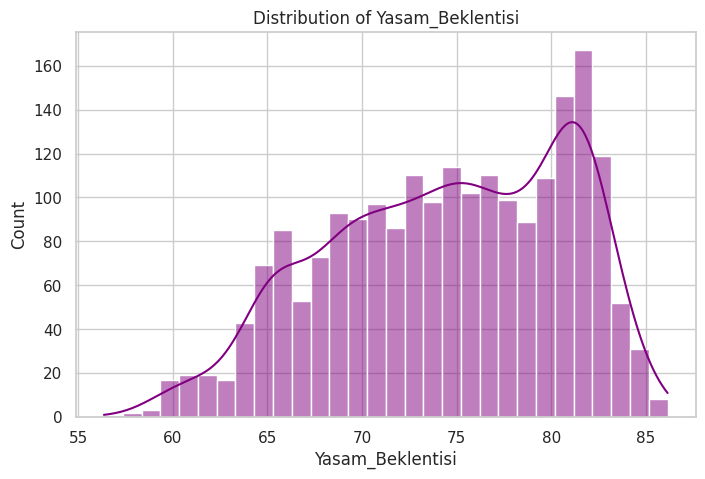

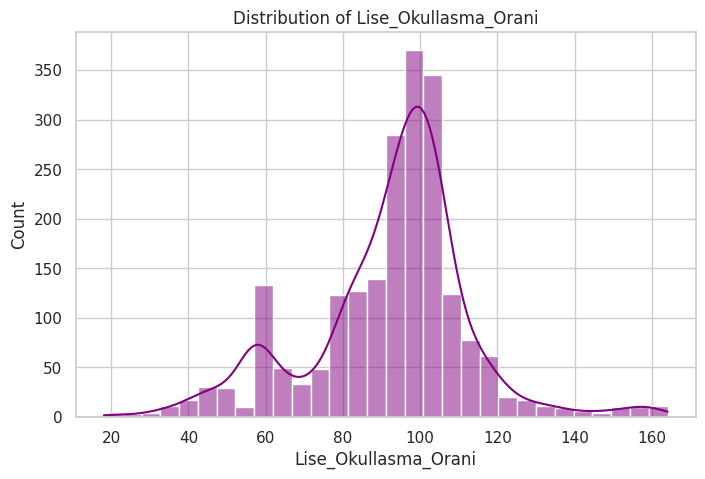

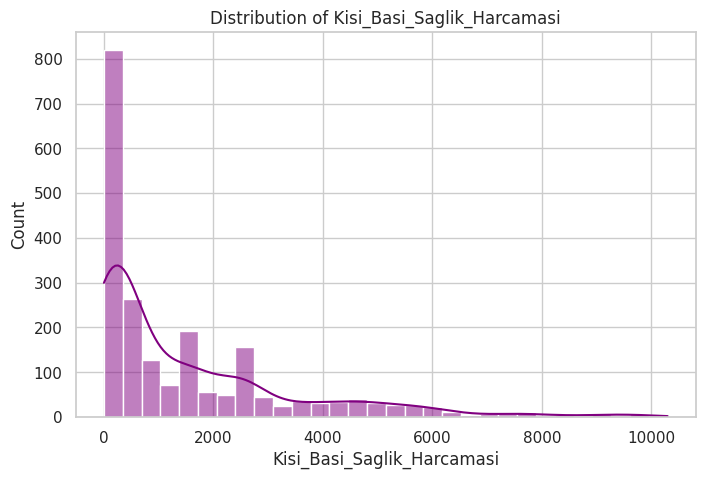

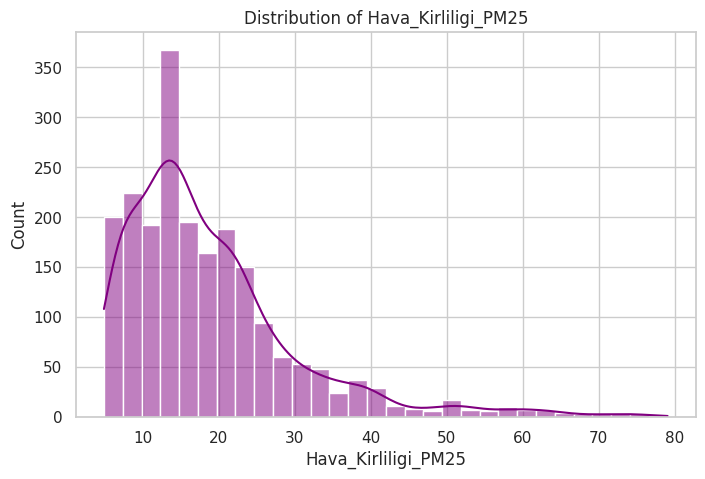

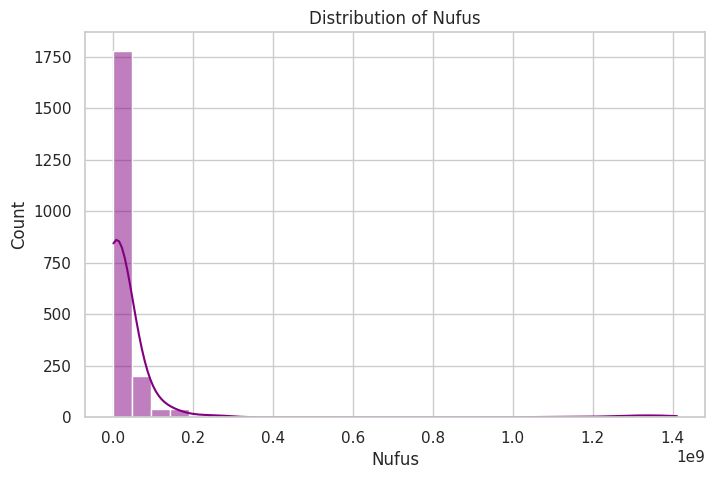

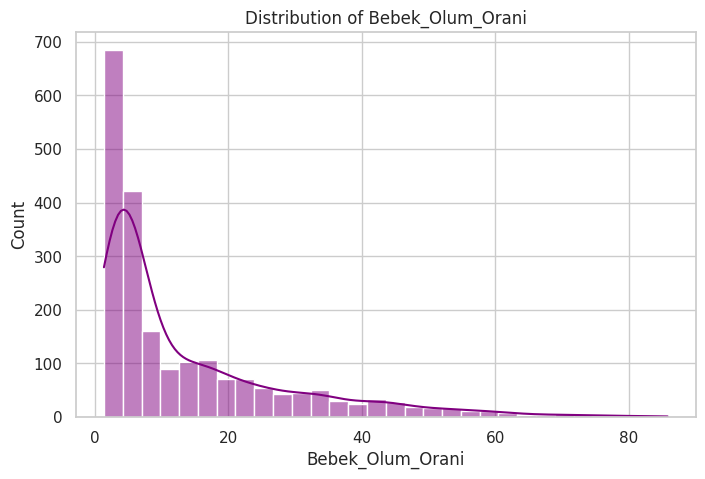

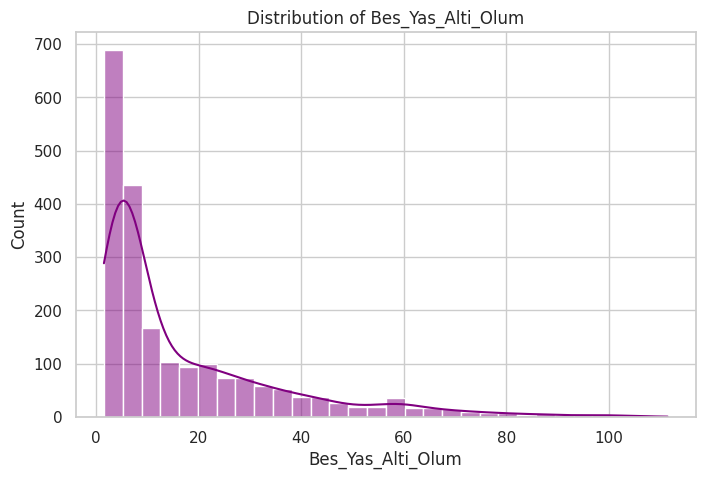

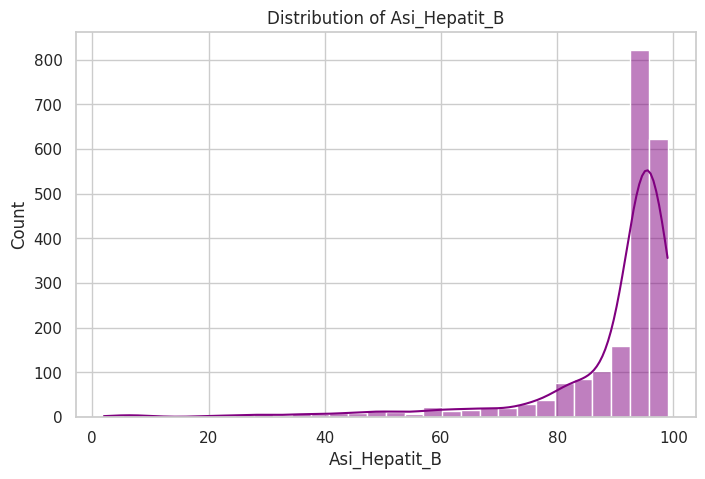

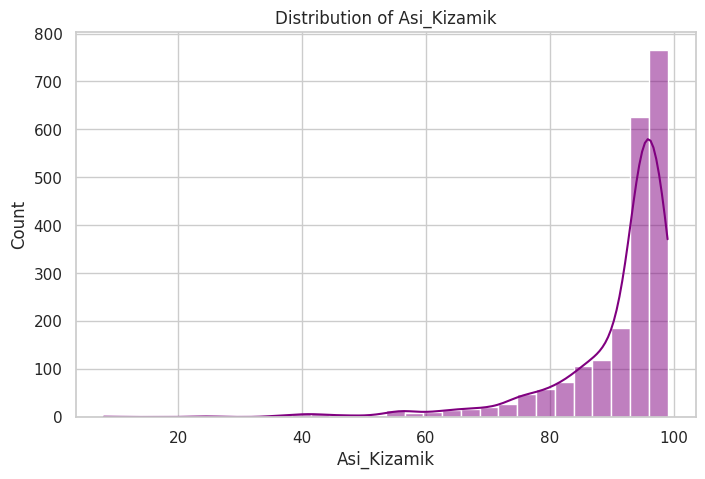

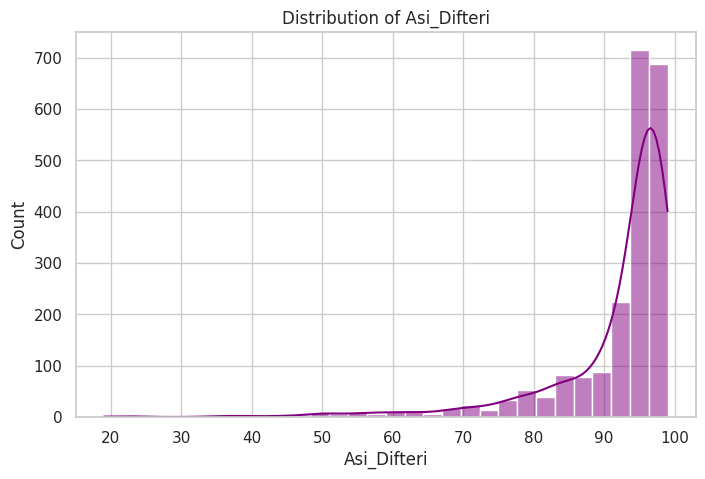

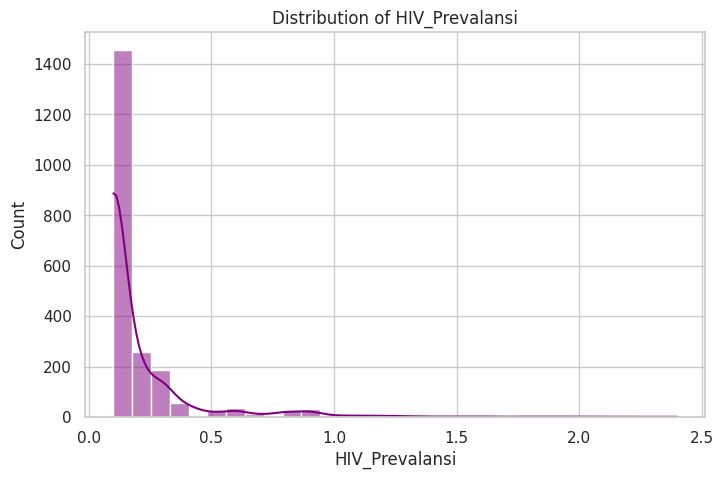

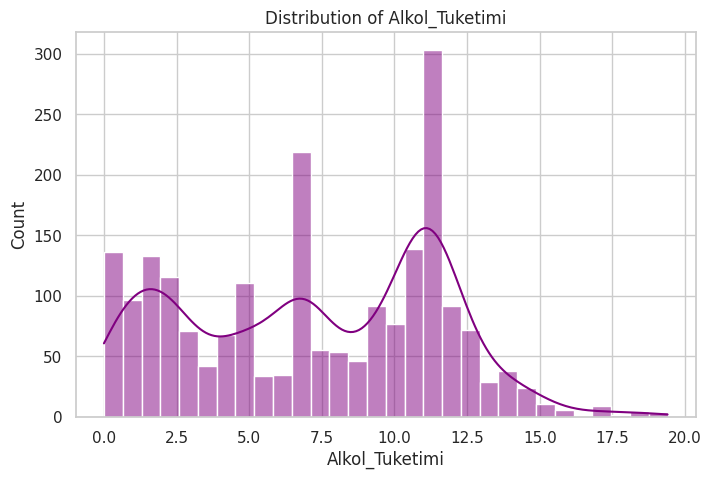

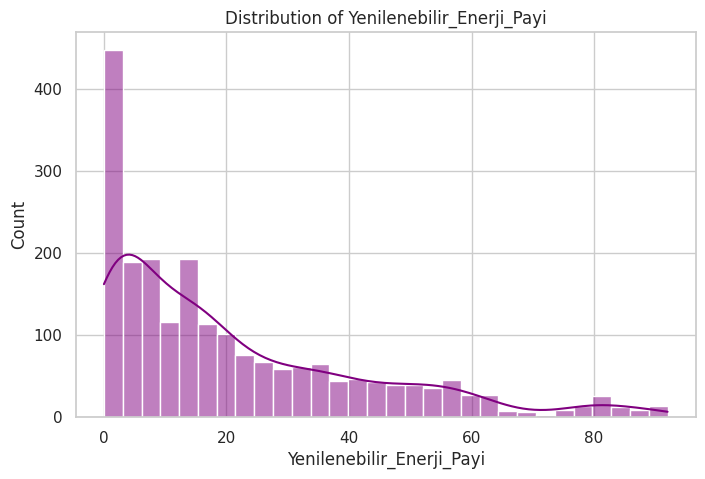

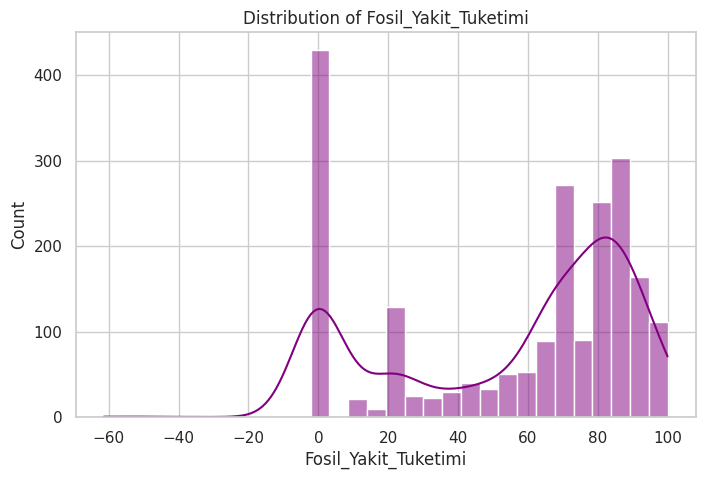

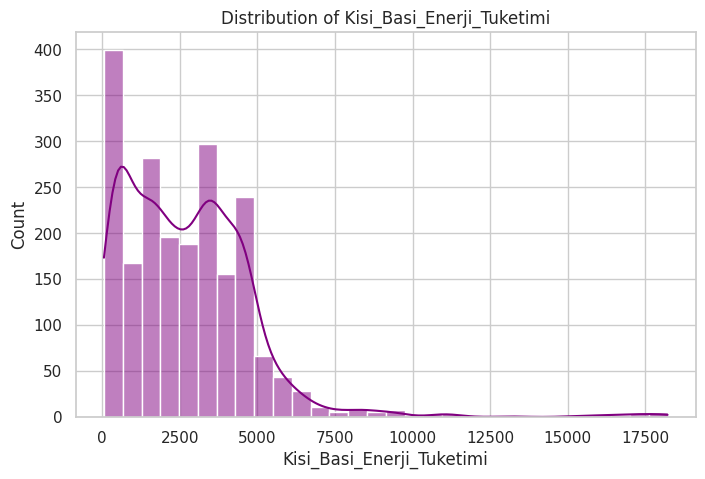

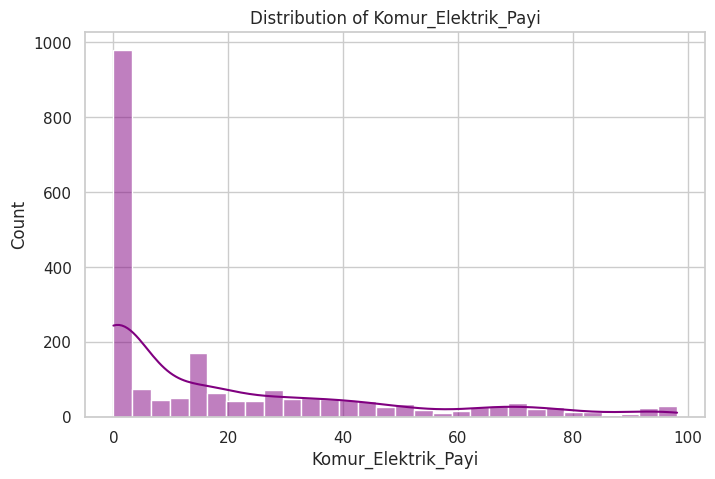

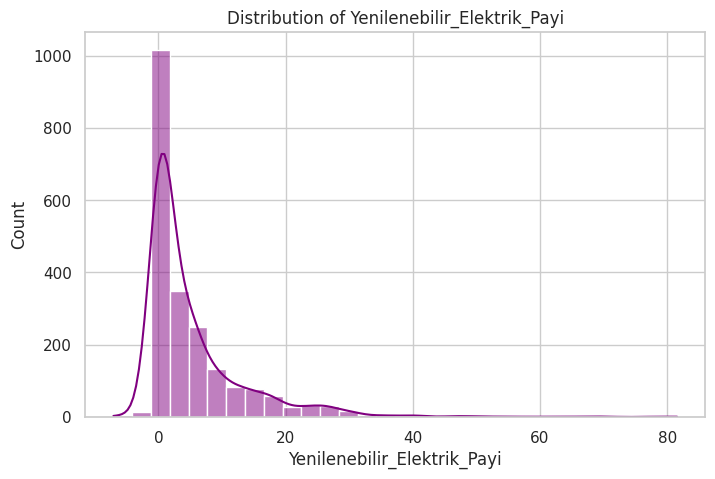

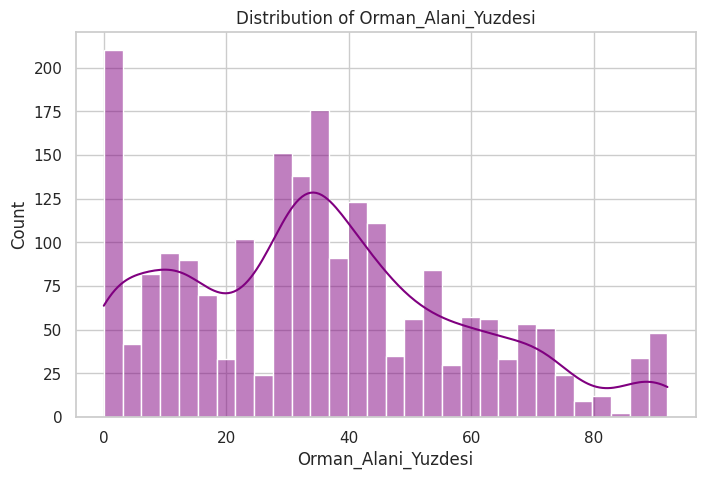

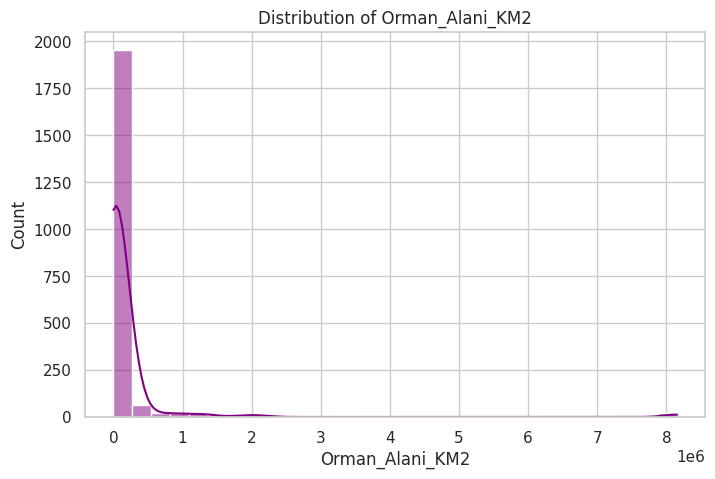

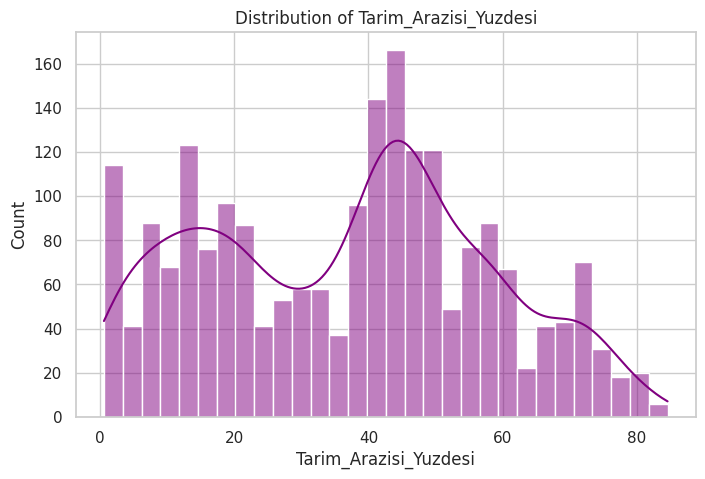

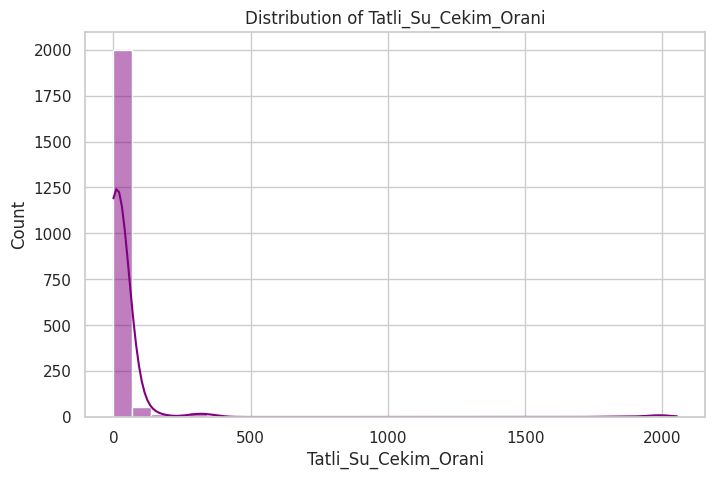

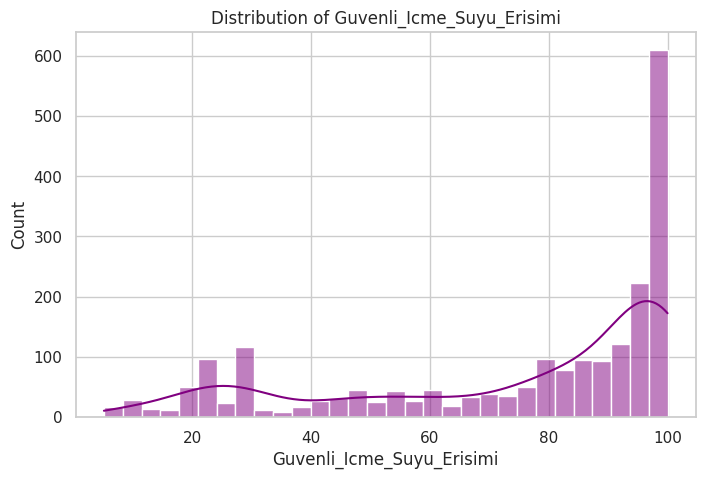

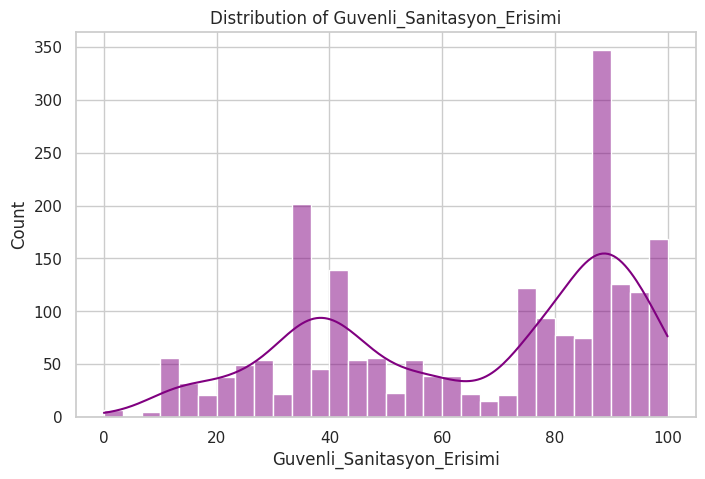

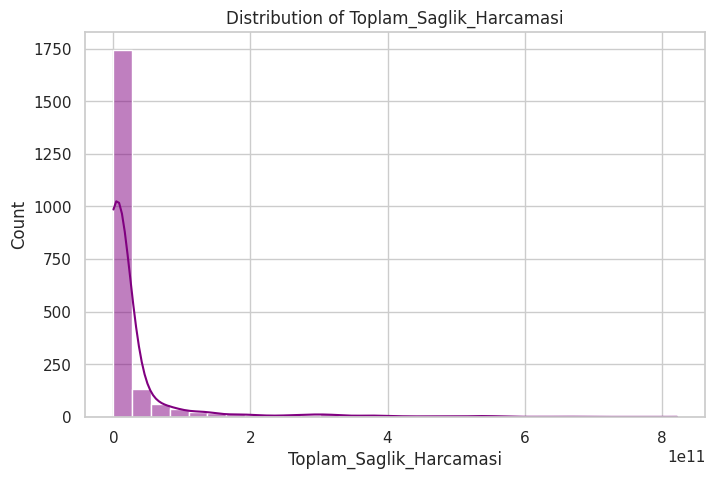

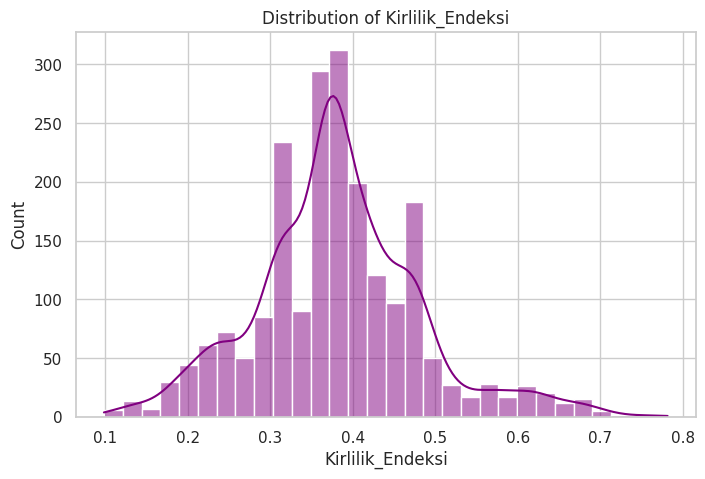

In [ ]:
# Tema ve genel ayarlar
sns.set(style="whitegrid", palette="pastel")
plt.rcParams['figure.figsize'] = (8, 5)

# Sayısal sütunları belirle
kategorik_sutunlar = ['Ulke_Kodu', 'Ulke_Adi', 'Kita', 'Gelismişlik_Durumu', 'Yil']
sayisal_sutunlar = df_analiz.select_dtypes(include=np.number).columns.tolist()
sayisal_sutunlar = [col for col in sayisal_sutunlar if col not in kategorik_sutunlar]

print("🔹 Sayısal sütunlar:", sayisal_sutunlar)

for col in sayisal_sutunlar:
    plt.figure()
    sns.histplot(df_analiz[col], kde=True, bins=30, color='purple')
    plt.title(f"Distribution of {col}")
    plt.show()


🔹 Kategorik sütunlar: ['Ulke_Kodu', 'Ulke_Adi', 'Kita', 'Gelismişlik_Durumu']


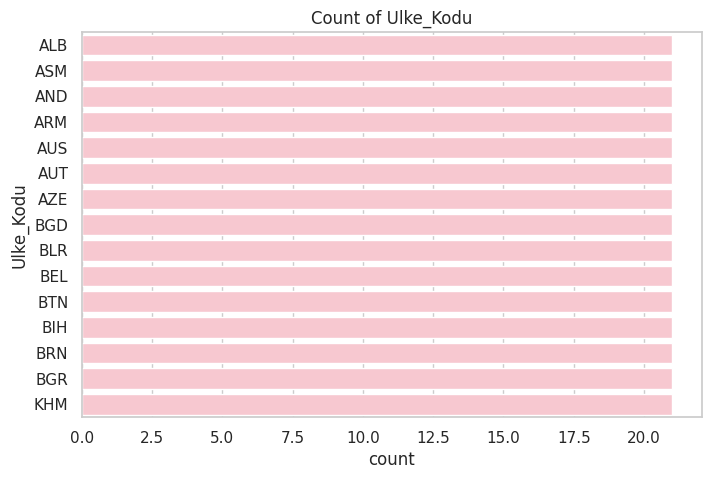

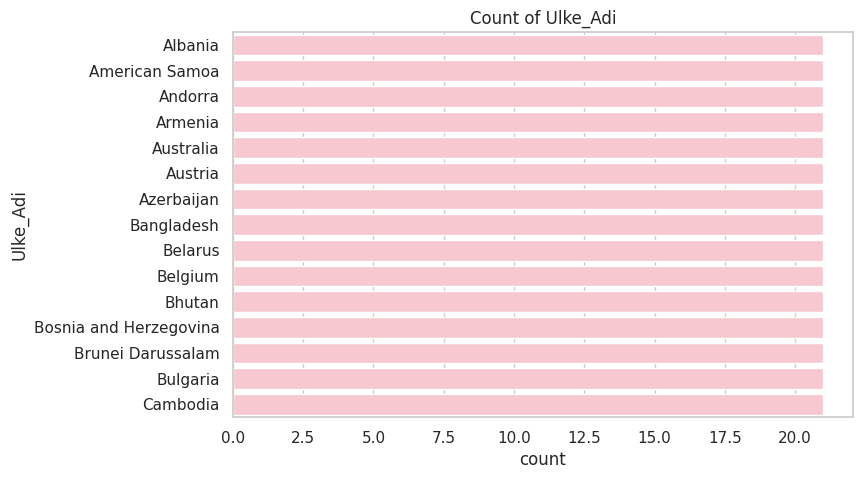

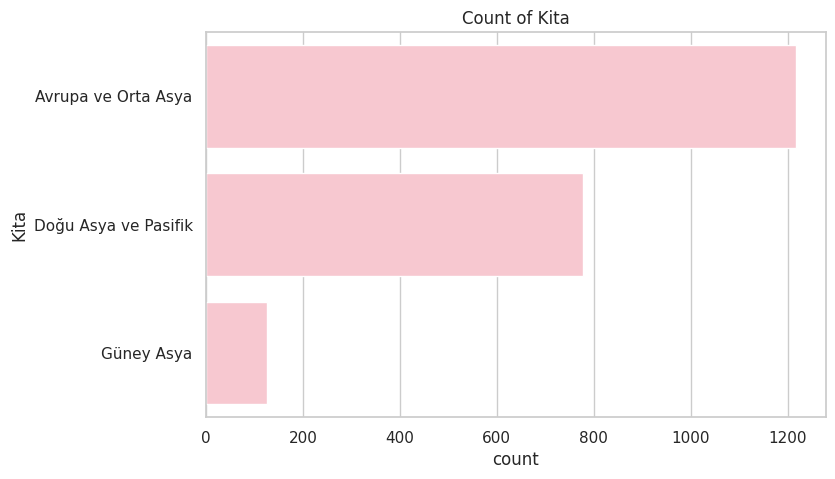

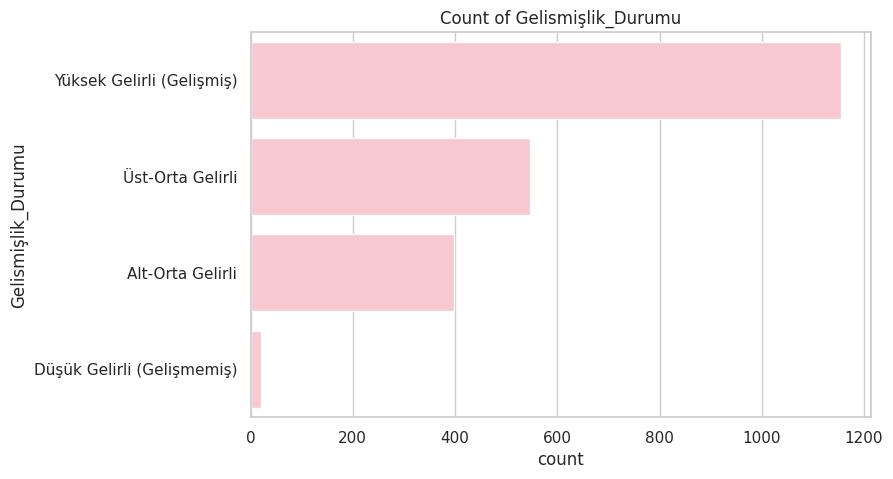

In [ ]:
# Kategorik sütunların frekans grafikleri
kategorik_sutunlar = ['Ulke_Kodu', 'Ulke_Adi', 'Kita', 'Gelismişlik_Durumu']
cat_cols = [col for col in kategorik_sutunlar if col in df_analiz.columns]

print("\n🔹 Kategorik sütunlar:", cat_cols)

for col in cat_cols:
    plt.figure()
    order = df_analiz[col].value_counts().index[:15]  # ilk 15 kategori
    sns.countplot(data=df_analiz, y=col, order=order, color='pink')
    plt.title(f"Count of {col}")
    plt.show()

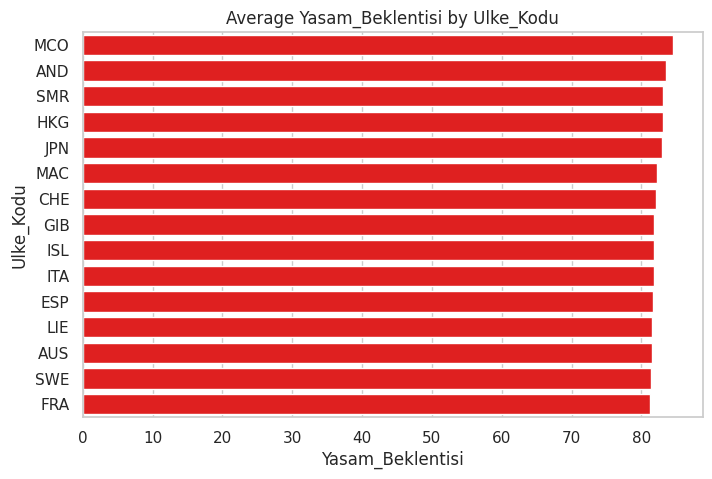

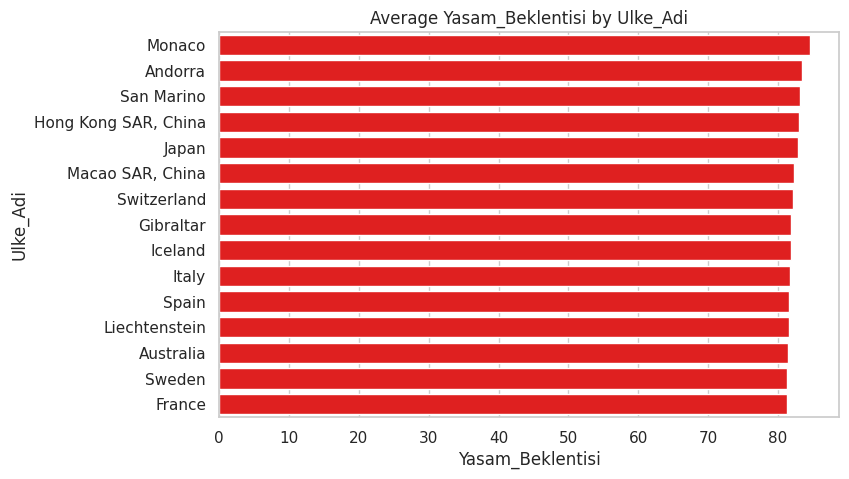

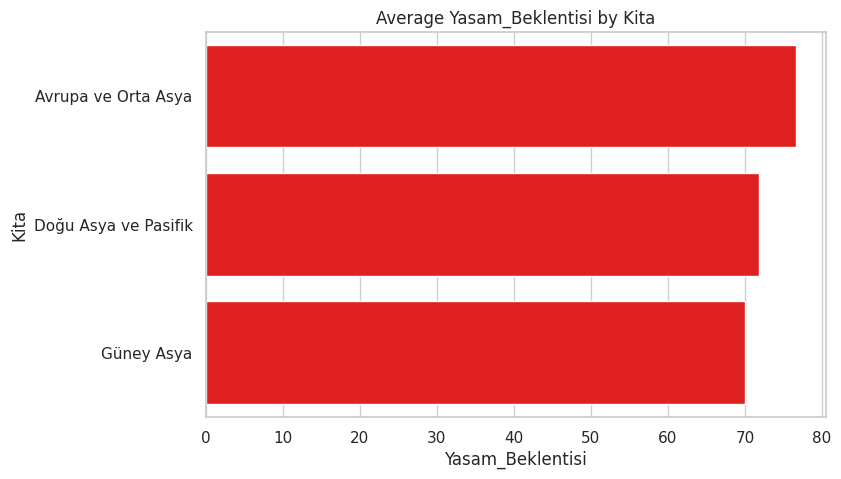

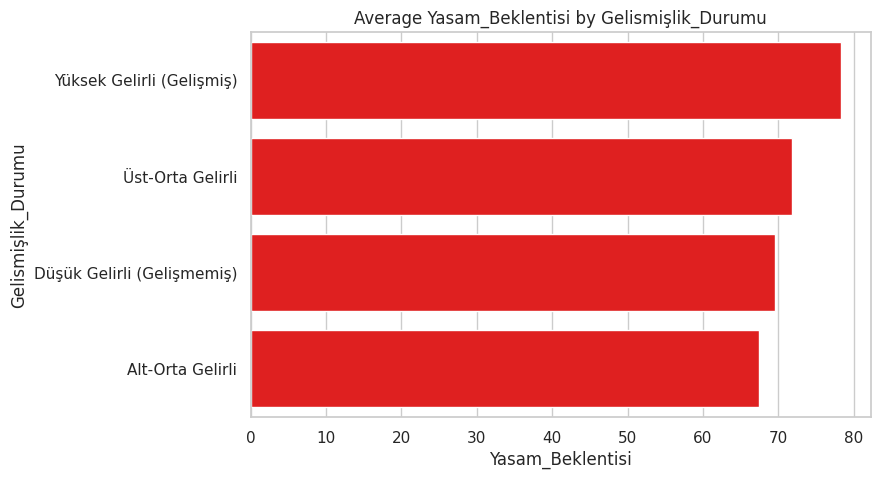

In [ ]:
# Hedef değişken ile kategorik sütunların ilişkisi
target_col = 'Yasam_Beklentisi'

kategorik_sutunlar = ['Ulke_Kodu', 'Ulke_Adi', 'Kita', 'Gelismişlik_Durumu']
cat_cols = [col for col in kategorik_sutunlar if col in df_analiz.columns]

for col in cat_cols:
    plt.figure()
    order = df_analiz.groupby(col)[target_col].mean().sort_values(ascending=False).index[:15]
    sns.barplot(data=df_analiz, x=target_col, y=col, order=order, color='red', estimator=np.mean, errorbar=None)
    plt.title(f"Average {target_col} by {col}")
    plt.show()

In [ ]:
df_analiz.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2121 entries, 0 to 2120
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Ulke_Kodu                    2121 non-null   object 
 1   Ulke_Adi                     2121 non-null   object 
 2   Kita                         2121 non-null   object 
 3   Gelismişlik_Durumu           2121 non-null   object 
 4   Yil                          2121 non-null   int64  
 5   Yasam_Beklentisi             2121 non-null   float64
 6   Lise_Okullasma_Orani         2121 non-null   float64
 7   Kisi_Basi_Saglik_Harcamasi   2121 non-null   float64
 8   Hava_Kirliligi_PM25          2121 non-null   float64
 9   Nufus                        2121 non-null   float64
 10  Bebek_Olum_Orani             2121 non-null   float64
 11  Bes_Yas_Alti_Olum            2121 non-null   float64
 12  Asi_Hepatit_B                2121 non-null   float64
 13  Asi_Kizamik       

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Ulke_Adi üzerinden tek encoding (daha okunabilir)
le = LabelEncoder()
df_analiz['Ulke_Kod'] = le.fit_transform(df_analiz['Ulke_Adi'])

# Eşleşme tablosu
ulke_esleme = pd.DataFrame({
    'Ulke_Adi': le.classes_,
    'Ulke_Kod': range(len(le.classes_))
})
print(f"✓ {len(le.classes_)} ülke encode edildi")
print("\nİlk 10 eşleşme:")
print(ulke_esleme.head(10))

# Ulke_Kodu sütununu artık bırakabiliriz (Ulke_Kod yeterli)
df_analiz.drop(columns=['Ulke_Kodu_Kod', 'Ulke_Adi_Kod'], errors='ignore', inplace=True)

# Sıralı encoding'i de tekrar uygula (önceki adımdan geldiyse)
sirali_kategoriler = {
    'Gelismişlik_Durumu': [
        'Düşük Gelirli (Gelişmemiş)',
        'Alt-Orta Gelirli',
        'Üst-Orta Gelirli',
        'Yüksek Gelirli (Gelişmiş)'
    ],
    'Kita': [
        'Güney Asya',
        'Doğu Asya ve Pasifik',
        'Avrupa ve Orta Asya'
    ]
}

for col, sira in sirali_kategoriler.items():
    yeni_col = col + '_Kod'
    df_analiz[yeni_col] = df_analiz[col].map({k: i for i, k in enumerate(sira)})

# Final kontrol
kod_sutunlar = [col for col in df_analiz.columns if col.endswith('_Kod')]
print(f"\n✓ Toplam encoding sütunları: {kod_sutunlar}")
print(df_analiz[['Ulke_Adi', 'Ulke_Kod', 'Kita', 'Kita_Kod', 'Gelismişlik_Durumu', 'Gelismişlik_Durumu_Kod']].head(8))

✓ 101 ülke encode edildi

İlk 10 eşleşme:
         Ulke_Adi  Ulke_Kod
0         Albania         0
1  American Samoa         1
2         Andorra         2
3         Armenia         3
4       Australia         4
5         Austria         5
6      Azerbaijan         6
7      Bangladesh         7
8         Belarus         8
9         Belgium         9

✓ Toplam encoding sütunları: ['Ulke_Kod', 'Gelismişlik_Durumu_Kod', 'Kita_Kod']
  Ulke_Adi  Ulke_Kod                 Kita  Kita_Kod Gelismişlik_Durumu  \
0  Albania         0  Avrupa ve Orta Asya         2   Üst-Orta Gelirli   
1  Albania         0  Avrupa ve Orta Asya         2   Üst-Orta Gelirli   
2  Albania         0  Avrupa ve Orta Asya         2   Üst-Orta Gelirli   
3  Albania         0  Avrupa ve Orta Asya         2   Üst-Orta Gelirli   
4  Albania         0  Avrupa ve Orta Asya         2   Üst-Orta Gelirli   
5  Albania         0  Avrupa ve Orta Asya         2   Üst-Orta Gelirli   
6  Albania         0  Avrupa ve Orta Asya         2

In [ ]:
# --- KALİTE KONTROL MERKEZİ ---

# final_df oluştur: orijinal sütunları koru, encode edilmiş halleri ekle
final_df = df_analiz.drop(columns=['Ulke_Kodu', 'Ulke_Adi', 'Kita', 'Gelismişlik_Durumu'], errors='ignore').copy()

if 'final_df' in locals():
    print("✅ DURUM: 'final_df' başarıyla tespit edildi.")
    print("-" * 50)

    # 1. İlk 5 Satır Kontrolü
    print("1. MODEL İÇİN HAZIR VERİNİN İLK 5 SATIRI:")
    display(final_df.head())

    # 2. Veri Tipi ve Bellek Kontrolü
    print("\n2. VERİ TİPLERİ VE BELLEK KONTROLÜ:")
    final_df.info()

    # 3. Sayısal Olmayan Sütun Kontrolü
    non_numeric = final_df.select_dtypes(exclude=[np.number]).columns.tolist()
    if len(non_numeric) == 0:
        print("\n🚀 SONUÇ: Tüm sütunlar sayısal hale getirilmiş. Model eğitimine HAZIR!")
    else:
        print(f"\n⚠️ DİKKAT: Hâlâ sayısal olmayan sütunlar var: {non_numeric}")

    # 4. Eksik Veri Kontrolü
    nan_count = final_df.isnull().sum().sum()
    if nan_count == 0:
        print("✅ EKSİK VERİ: Hiç NaN değer kalmadı, veri seti temiz.")
    else:
        print(f"⚠️ UYARI: Toplam {nan_count} adet eksik (NaN) değer bulundu!")
        print(final_df.isnull().sum()[final_df.isnull().sum() > 0])

    # 5. Boyut Kontrolü
    print(f"\n3. VERİ SETİ BOYUTU:")
    print(f"   Satır : {final_df.shape[0]}")
    print(f"   Sütun : {final_df.shape[1]}")

    # 6. Sütun Listesi
    print(f"\n4. SÜTUN LİSTESİ ({final_df.shape[1]} adet):")
    for i, col in enumerate(final_df.columns, 1):
        print(f"   {i:02d}. {col} ({final_df[col].dtype})")

else:
    print("❌ HATA: 'final_df' henüz oluşturulmamış! Lütfen önce ön işleme hücresini çalıştırın.")

✅ DURUM: 'final_df' başarıyla tespit edildi.
--------------------------------------------------
1. MODEL İÇİN HAZIR VERİNİN İLK 5 SATIRI:


,Yil,Yasam_Beklentisi,Lise_Okullasma_Orani,Kisi_Basi_Saglik_Harcamasi,Hava_Kirliligi_PM25,Nufus,Bebek_Olum_Orani,Bes_Yas_Alti_Olum,Asi_Hepatit_B,Asi_Kizamik,...,Orman_Alani_KM2,Tarim_Arazisi_Yuzdesi,Tatli_Su_Cekim_Orani,Guvenli_Icme_Suyu_Erisimi,Guvenli_Sanitasyon_Erisimi,Toplam_Saglik_Harcamasi,Kirlilik_Endeksi,Ulke_Kod,Gelismişlik_Durumu_Kod,Kita_Kod
0,2000,74.826,70.318649,65.476746,22.265189,3089027.0,17.8,27.0,96.0,95.0,...,7693.00,41.751825,6.831970,49.138320,22.879987,2.022594e+08,0.322910,0,2,2
1,2001,75.083,72.484573,73.921715,22.366006,3060173.0,17.0,25.6,96.0,95.0,...,7705.77,41.569343,6.507286,49.081199,23.475974,2.262132e+08,0.329457,0,2,2
2,2002,75.299,74.538918,78.729095,22.482785,3051010.0,16.1,24.3,96.0,96.0,...,7718.54,41.605839,6.182602,48.984766,24.036737,2.402033e+08,0.337019,0,2,2
3,2003,75.557,77.751823,105.436676,22.593449,3039616.0,15.2,22.9,97.0,93.0,...,7731.31,40.912409,5.857918,48.885443,24.576771,3.204870e+08,0.341808,0,2,2
4,2004,75.951,78.980186,136.507248,22.675923,3026939.0,14.4,21.4,99.0,96.0,...,7744.08,40.948905,5.533234,50.717678,25.095910,4.131991e+08,0.341520,0,2,2



2. VERİ TİPLERİ VE BELLEK KONTROLÜ:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2121 entries, 0 to 2120
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Yil                          2121 non-null   int64  
 1   Yasam_Beklentisi             2121 non-null   float64
 2   Lise_Okullasma_Orani         2121 non-null   float64
 3   Kisi_Basi_Saglik_Harcamasi   2121 non-null   float64
 4   Hava_Kirliligi_PM25          2121 non-null   float64
 5   Nufus                        2121 non-null   float64
 6   Bebek_Olum_Orani             2121 non-null   float64
 7   Bes_Yas_Alti_Olum            2121 non-null   float64
 8   Asi_Hepatit_B                2121 non-null   float64
 9   Asi_Kizamik                  2121 non-null   float64
 10  Asi_Difteri                  2121 non-null   float64
 11  HIV_Prevalansi               2121 non-null   float64
 12  Alkol_Tuketimi               2121 non-n

In [ ]:
from sklearn.model_selection import train_test_split

if 'final_df' in locals():
    # 1. X (Özellikler) ve y (Hedef) olarak ayır
    X = final_df.drop('Yasam_Beklentisi', axis=1)
    y = final_df['Yasam_Beklentisi']

    print("--- X (Özellikler) Verisinin İlk 5 Satırı ---")
    display(X.head())

    print("\n--- y (Hedef) Verisinin İlk 5 Satırı ---")
    print(y.head())

    # 2. Veriyi Eğitim (Train) ve Test olarak ayır
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,   # Verinin %20'si test için ayrılacak
        random_state=42  # Sonuçların tekrarlanabilir olması için
    )

    print("\n--- Veri Ayırma İşlemi Tamamlandı ---")
    print(f"Toplam veri boyutu          : {final_df.shape[0]} satır")
    print(f"Eğitim verisi (X_train)     : {X_train.shape[0]} satır, {X_train.shape[1]} sütun")
    print(f"Test verisi    (X_test)     : {X_test.shape[0]} satır, {X_test.shape[1]} sütun")
    print(f"\nHedef değişken (y)          : Yasam_Beklentisi")
    print(f"  Eğitim seti ort. değeri   : {y_train.mean():.2f} yıl")
    print(f"  Test seti ort. değeri     : {y_test.mean():.2f} yıl")

else:
    print("❌ HATA: 'final_df' henüz oluşturulmamış! Lütfen önce ön işleme hücresini çalıştırın.")

--- X (Özellikler) Verisinin İlk 5 Satırı ---


,Yil,Lise_Okullasma_Orani,Kisi_Basi_Saglik_Harcamasi,Hava_Kirliligi_PM25,Nufus,Bebek_Olum_Orani,Bes_Yas_Alti_Olum,Asi_Hepatit_B,Asi_Kizamik,Asi_Difteri,...,Orman_Alani_KM2,Tarim_Arazisi_Yuzdesi,Tatli_Su_Cekim_Orani,Guvenli_Icme_Suyu_Erisimi,Guvenli_Sanitasyon_Erisimi,Toplam_Saglik_Harcamasi,Kirlilik_Endeksi,Ulke_Kod,Gelismişlik_Durumu_Kod,Kita_Kod
0,2000,70.318649,65.476746,22.265189,3089027.0,17.8,27.0,96.0,95.0,97.0,...,7693.00,41.751825,6.831970,49.138320,22.879987,2.022594e+08,0.322910,0,2,2
1,2001,72.484573,73.921715,22.366006,3060173.0,17.0,25.6,96.0,95.0,97.0,...,7705.77,41.569343,6.507286,49.081199,23.475974,2.262132e+08,0.329457,0,2,2
2,2002,74.538918,78.729095,22.482785,3051010.0,16.1,24.3,96.0,96.0,98.0,...,7718.54,41.605839,6.182602,48.984766,24.036737,2.402033e+08,0.337019,0,2,2
3,2003,77.751823,105.436676,22.593449,3039616.0,15.2,22.9,97.0,93.0,97.0,...,7731.31,40.912409,5.857918,48.885443,24.576771,3.204870e+08,0.341808,0,2,2
4,2004,78.980186,136.507248,22.675923,3026939.0,14.4,21.4,99.0,96.0,97.0,...,7744.08,40.948905,5.533234,50.717678,25.095910,4.131991e+08,0.341520,0,2,2



--- y (Hedef) Verisinin İlk 5 Satırı ---
0    74.826
1    75.083
2    75.299
3    75.557
4    75.951
Name: Yasam_Beklentisi, dtype: float64

--- Veri Ayırma İşlemi Tamamlandı ---
Toplam veri boyutu          : 2121 satır
Eğitim verisi (X_train)     : 1696 satır, 28 sütun
Test verisi    (X_test)     : 425 satır, 28 sütun

Hedef değişken (y)          : Yasam_Beklentisi
  Eğitim seti ort. değeri   : 74.36 yıl
  Test seti ort. değeri     : 75.00 yıl


In [ ]:
train_data = pd.concat([X_train, y_train], axis=1)
test_data = pd.concat([X_test, y_test], axis=1)

# Kontrol edilecek sayısal sütunlar (hedef dahil)
numerical_features = [col for col in X_train.select_dtypes(include=np.number).columns.tolist()]
numerical_features.append('Yasam_Beklentisi')
bounds = {}

print("--- Aykırı Değer Sınırları (Eğitim Verisinden Hesaplanıyor) ---")

# 1. Eğitim verisinden sınırları hesapla
for col in numerical_features:
    Q1 = train_data[col].quantile(0.25)
    Q3 = train_data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    bounds[col] = (lower_bound, upper_bound)
    print(f"  '{col}' için Sınırlar: ({lower_bound:.2f}, {upper_bound:.2f})")

# 2. Eğitim verisini filtrele
train_mask = pd.Series(True, index=train_data.index)
for col in numerical_features:
    train_mask &= (train_data[col] >= bounds[col][0]) & (train_data[col] <= bounds[col][1])
train_data_cleaned = train_data[train_mask]

# 3. Aynı sınırlarla test verisini filtrele
test_mask = pd.Series(True, index=test_data.index)
for col in numerical_features:
    test_mask &= (test_data[col] >= bounds[col][0]) & (test_data[col] <= bounds[col][1])
test_data_cleaned = test_data[test_mask]

# 4. Temizlenmiş verileri tekrar X ve y olarak ayır
X_train_cleaned = train_data_cleaned.drop('Yasam_Beklentisi', axis=1)
y_train_cleaned = train_data_cleaned['Yasam_Beklentisi']

X_test_cleaned = test_data_cleaned.drop('Yasam_Beklentisi', axis=1)
y_test_cleaned = test_data_cleaned['Yasam_Beklentisi']

# 5. Sonuç karşılaştırması
print("\n--- Veri Boyutu Karşılaştırması ---")
print(f"Orijinal Eğitim Verisi    : {X_train.shape[0]} satır")
print(f"Temizlenmiş Eğitim Verisi : {X_train_cleaned.shape[0]} satır")
print(f"Kaldırılan Satır (Eğitim) : {X_train.shape[0] - X_train_cleaned.shape[0]}")
print("-" * 40)
print(f"Orijinal Test Verisi      : {X_test.shape[0]} satır")
print(f"Temizlenmiş Test Verisi   : {X_test_cleaned.shape[0]} satır")
print(f"Kaldırılan Satır (Test)   : {X_test.shape[0] - X_test_cleaned.shape[0]}")

--- Aykırı Değer Sınırları (Eğitim Verisinden Hesaplanıyor) ---
  'Yil' için Sınırlar: (1990.00, 2030.00)
  'Lise_Okullasma_Orani' için Sınırlar: (51.96, 135.07)
  'Kisi_Basi_Saglik_Harcamasi' için Sınırlar: (-3120.66, 5613.71)
  'Hava_Kirliligi_PM25' için Sınırlar: (-5.60, 39.69)
  'Nufus' için Sınırlar: (-29004043.38, 49417899.62)
  'Bebek_Olum_Orani' için Sınırlar: (-19.85, 42.95)
  'Bes_Yas_Alti_Olum' için Sınırlar: (-24.59, 52.71)
  'Asi_Hepatit_B' için Sınırlar: (81.00, 105.00)
  'Asi_Kizamik' için Sınırlar: (77.00, 109.00)
  'Asi_Difteri' için Sınırlar: (82.00, 106.00)
  'HIV_Prevalansi' için Sınırlar: (-0.05, 0.35)
  'Alkol_Tuketimi' için Sınırlar: (-9.20, 23.35)
  'Yenilenebilir_Enerji_Payi' için Sınırlar: (-38.91, 75.19)
  'Fosil_Yakit_Tuketimi' için Sınırlar: (-72.89, 178.11)
  'Kisi_Basi_Enerji_Tuketimi' için Sınırlar: (-3286.57, 8288.47)
  'Komur_Elektrik_Payi' için Sınırlar: (-50.51, 84.18)
  'Yenilenebilir_Elektrik_Payi' için Sınırlar: (-9.01, 15.41)
  'Orman_Alani_Yuzde

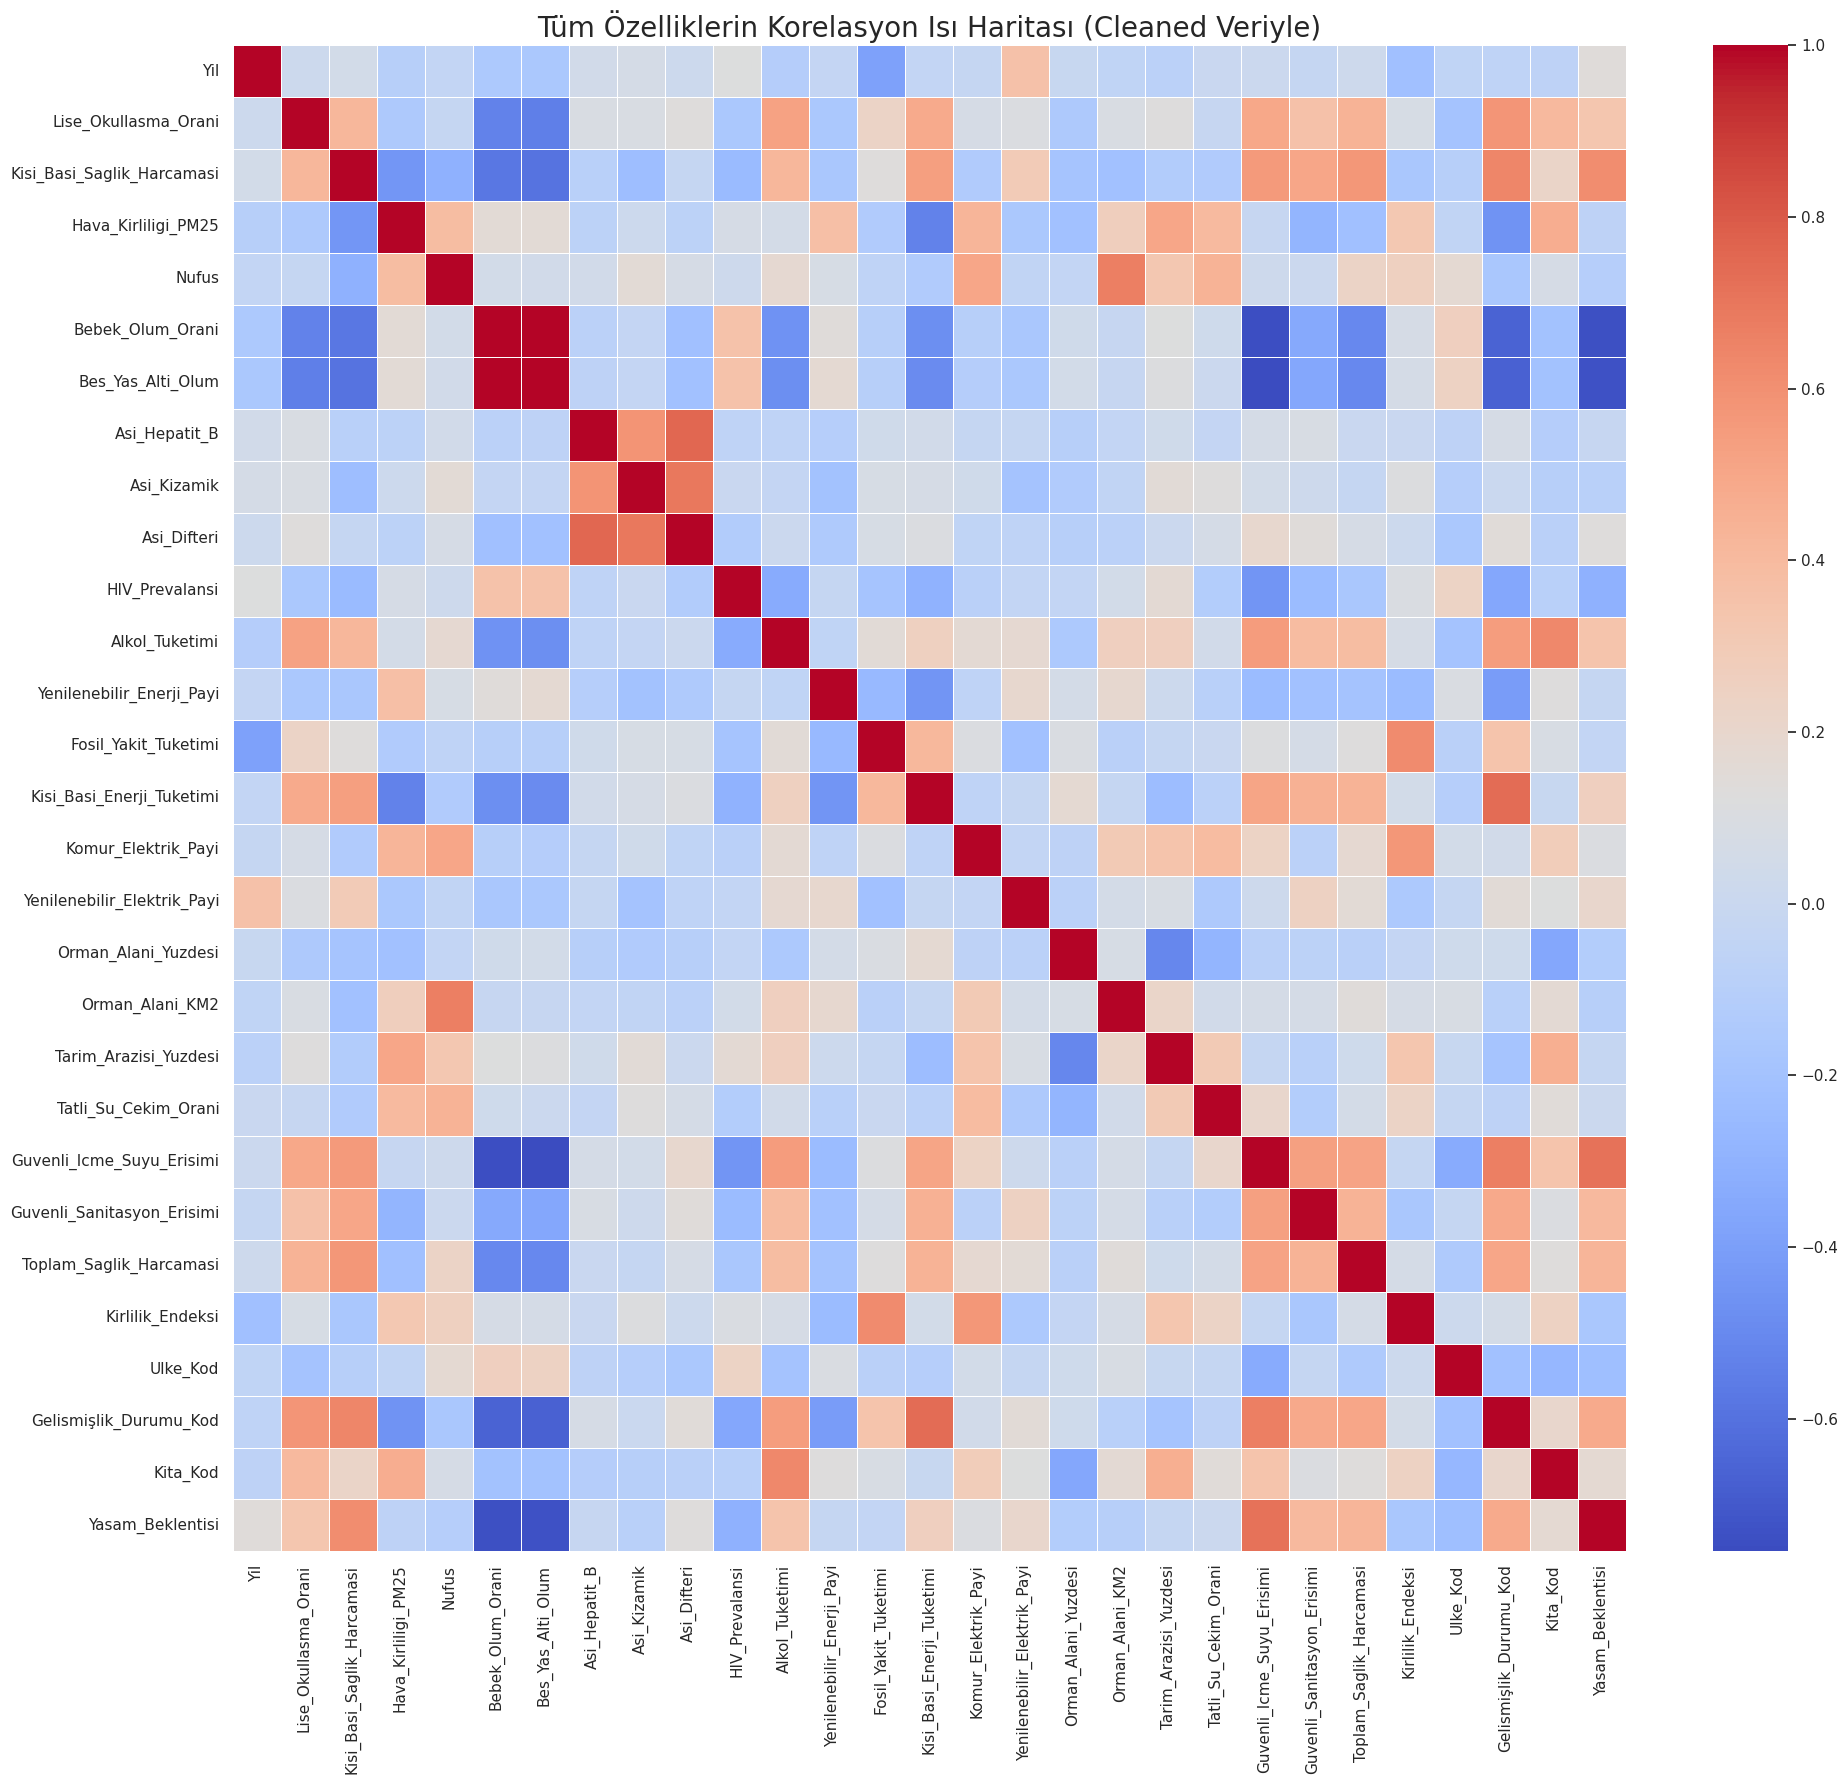


--- Yasam_Beklentisi ile Korelasyonlar (Yüksekten Düşüğe) ---
Guvenli_Icme_Suyu_Erisimi      0.717388
Kisi_Basi_Saglik_Harcamasi     0.610822
Gelismişlik_Durumu_Kod         0.484375
Toplam_Saglik_Harcamasi        0.429684
Guvenli_Sanitasyon_Erisimi     0.406895
Alkol_Tuketimi                 0.343254
Lise_Okullasma_Orani           0.333809
Kisi_Basi_Enerji_Tuketimi      0.260625
Yenilenebilir_Elektrik_Payi    0.203780
Kita_Kod                       0.173047
Yil                            0.139513
Asi_Difteri                    0.132720
Komur_Elektrik_Payi            0.108764
Tatli_Su_Cekim_Orani           0.011975
Asi_Hepatit_B                 -0.020975
Tarim_Arazisi_Yuzdesi         -0.022523
Yenilenebilir_Enerji_Payi     -0.027142
Fosil_Yakit_Tuketimi          -0.034872
Hava_Kirliligi_PM25           -0.067261
Asi_Kizamik                   -0.091170
Orman_Alani_KM2               -0.097966
Nufus                         -0.105944
Orman_Alani_Yuzdesi           -0.118461
Kirlilik_Endeksi 

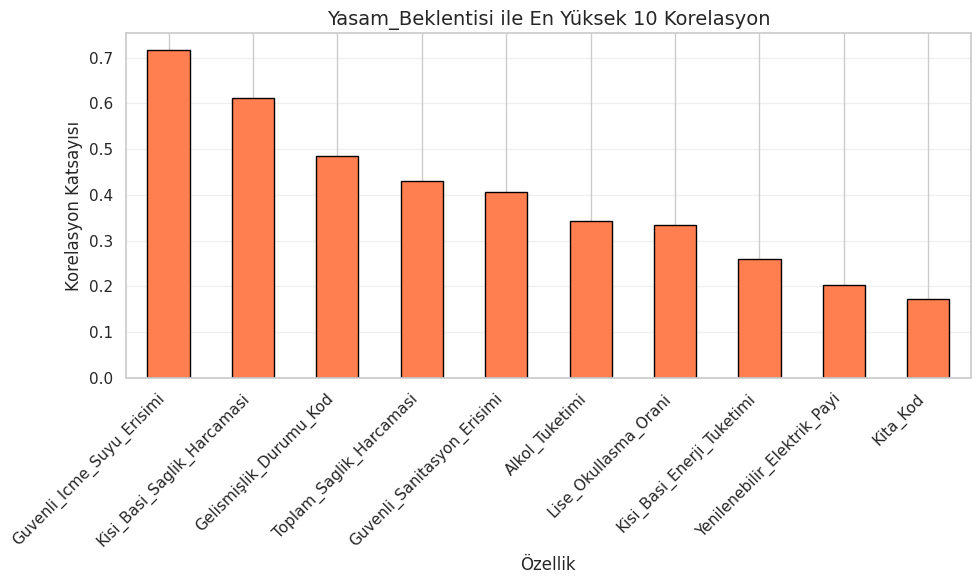


--- ⚠️ Yüksek Korelasyonlu Özellik Çiftleri (|r| > 0.85) ---


,Özellik 1,Özellik 2,Korelasyon
0,Bebek_Olum_Orani,Bes_Yas_Alti_Olum,0.996


In [ ]:
# 1. Temizlenmiş eğitim verisini birleştir
try:
    temp_df = pd.concat([X_train_cleaned, y_train_cleaned], axis=1)
except NameError:
    print("HATA: 'X_train_cleaned' veya 'y_train_cleaned' verileri bulunamadı.")
    raise

# 2. Korelasyon matrisi hesapla
corr_matrix = temp_df.corr(numeric_only=True)

# 3. Tüm korelasyon ısı haritası
plt.figure(figsize=(20, 18))
sns.heatmap(corr_matrix,
            annot=False,
            cmap="coolwarm",
            linewidths=0.5)
plt.title("Tüm Özelliklerin Korelasyon Isı Haritası (Cleaned Veriyle)", fontsize=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 4. Hedef değişkenle (Yasam_Beklentisi) korelasyonlar
print("\n--- Yasam_Beklentisi ile Korelasyonlar (Yüksekten Düşüğe) ---")
hedef_corr = corr_matrix['Yasam_Beklentisi'].drop('Yasam_Beklentisi').sort_values(ascending=False)
print(hedef_corr.to_string())

# 5. Hedef değişkenle en güçlü 10 korelasyon (bar plot)
plt.figure(figsize=(10, 6))
hedef_corr.head(10).plot(kind='bar', color='coral', edgecolor='black')
plt.axhline(0, color='black', linewidth=0.8)
plt.title("Yasam_Beklentisi ile En Yüksek 10 Korelasyon", fontsize=14)
plt.xlabel("Özellik")
plt.ylabel("Korelasyon Katsayısı")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 6. Yüksek korelasyonlu özellik çiftleri (multicollinearity uyarısı)
print("\n--- ⚠️ Yüksek Korelasyonlu Özellik Çiftleri (|r| > 0.85) ---")
yuksek_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.85:
            yuksek_corr.append({
                'Özellik 1': corr_matrix.columns[i],
                'Özellik 2': corr_matrix.columns[j],
                'Korelasyon': round(r, 3)
            })

if yuksek_corr:
    display(pd.DataFrame(yuksek_corr).sort_values('Korelasyon', ascending=False))
else:
    print("✅ Yüksek korelasyonlu özellik çifti bulunamadı.")

In [ ]:
X_train_cleaned = X_train_cleaned.drop(columns=['Bes_Yas_Alti_Olum'])
X_test_cleaned  = X_test_cleaned.drop(columns=['Bes_Yas_Alti_Olum'])

print(f"✅ 'Bes_Yas_Alti_Olum' sütunu düşürüldü.")
print(f"Yeni X_train boyutu: {X_train_cleaned.shape}")
print(f"Yeni X_test boyutu : {X_test_cleaned.shape}")

✅ 'Bes_Yas_Alti_Olum' sütunu düşürüldü.
Yeni X_train boyutu: (682, 27)
Yeni X_test boyutu : (169, 27)


In [ ]:
import time
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Model Kütüphaneleri
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

import xgboost as xgb

In [ ]:
from sklearn.preprocessing import StandardScaler

print("--- Özellik Ölçeklendirme (StandardScaler) Başlatılıyor ---")

# 1. StandardScaler objesini oluştur
scaler = StandardScaler()

# 2. Ölçekleyiciyi SADECE EĞİTİM VERİSİNE uydur (fit)
scaler.fit(X_train_cleaned)

# 3. Hem eğitim hem de test verisini dönüştür (transform)
X_train_scaled = scaler.transform(X_train_cleaned)
X_test_scaled  = scaler.transform(X_test_cleaned)

print("--- Ölçeklendirme Tamamlandı ---")
print("Yeni değişkenler oluşturuldu: 'X_train_scaled' ve 'X_test_scaled'")

# 4. Örnek karşılaştırma (ilk satır, ilk 5 sütun)
print("\n--- Örnek Karşılaştırma (İlk Satır, İlk 5 Sütun) ---")
print(f"Önce : {X_train_cleaned.iloc[0, :5].values}")
print(f"Sonra: {X_train_scaled[0, :5]}")

# 5. Ölçekleme doğrulama: ortalama ≈ 0, std ≈ 1 olmalı
print("\n--- Ölçekleme Doğrulaması (Eğitim Verisi) ---")
import numpy as np
print(f"Ortalama (mean) → Beklenen: ~0.00  | Sonuç: {X_train_scaled.mean():.6f}")
print(f"Std Sapma (std) → Beklenen: ~1.00  | Sonuç: {X_train_scaled.std():.6f}")

# 6. Sütun bazlı özet
print("\n--- Sütun Bazlı Ölçekleme Özeti ---")
olcekleme_ozet = pd.DataFrame({
    'Sütun'     : X_train_cleaned.columns,
    'Orj. Ort.' : scaler.mean_.round(3),
    'Orj. Std'  : scaler.scale_.round(3),
}).set_index('Sütun')
display(olcekleme_ozet)

--- Özellik Ölçeklendirme (StandardScaler) Başlatılıyor ---
--- Ölçeklendirme Tamamlandı ---
Yeni değişkenler oluşturuldu: 'X_train_scaled' ve 'X_test_scaled'

--- Örnek Karşılaştırma (İlk Satır, İlk 5 Sütun) ---
Önce : [2.01500000e+03 1.09414787e+02 8.03959656e+02 2.24139831e+01
 3.79864120e+07]
Sonra: [ 0.91789194  1.22267711 -0.41425789  0.88000456  4.06133146]

--- Ölçekleme Doğrulaması (Eğitim Verisi) ---
Ortalama (mean) → Beklenen: ~0.00  | Sonuç: -0.000000
Std Sapma (std) → Beklenen: ~1.00  | Sonuç: 1.000000

--- Sütun Bazlı Ölçekleme Özeti ---


,Orj. Ort.,Orj. Std
Sütun,,
Yil,2.009484e+03,6.010000e+00
Lise_Okullasma_Orani,9.475300e+01,1.199100e+01
Kisi_Basi_Saglik_Harcamasi,1.236365e+03,1.043808e+03
Hava_Kirliligi_PM25,1.571700e+01,7.610000e+00
Nufus,4.653275e+06,8.207441e+06
Bebek_Olum_Orani,9.024000e+00,7.784000e+00
Asi_Hepatit_B,9.469900e+01,3.581000e+00
Asi_Kizamik,9.437400e+01,4.353000e+00
Asi_Difteri,9.522300e+01,3.527000e+00


In [ ]:
from sklearn.model_selection import cross_val_score

# --- Modellerin Tanımlanması ---
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost Regressor": xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
}

# --- Sonuçları Saklamak İçin Bir Liste ---
results_list = []

# --- Eğitim ve Değerlendirme Başlatılıyor ---
print("--- Tüm Modeller İçin Eğitim ve Değerlendirme Başlatılıyor ---")

# Her modeli sırayla eğit ve değerlendir
for name, model in models.items():
    print(f"\nModel eğitiliyor: {name}...")

    # 1. Eğitim süresini ölçmek için zamanlayıcıyı başlat
    start_time = time.time()

    # 2. Modeli eğit
    model.fit(X_train_scaled, y_train_cleaned)

    # 3. Test verisi üzerinde tahmin yap
    y_pred = model.predict(X_test_scaled)

    # 4. Eğitim süresini hesapla
    end_time = time.time()
    training_time = end_time - start_time

    # 5. Metrikleri Hesapla
    r2 = r2_score(y_test_cleaned, y_pred)
    mae = mean_absolute_error(y_test_cleaned, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_cleaned, y_pred))

    # 5-Fold Cross Validation (Çapraz Doğrulama)
    # Eğitim verisi üzerinde modelin kararlılığını test ediyoruz
    cv_scores = cross_val_score(model, X_train_scaled, y_train_cleaned, cv=5, scoring='r2')
    cv_mean = cv_scores.mean()

    # 6. Sonuçları listeye ekle
    results_list.append({
        "Model": name,
        "R2 Skoru": r2,
        'CV_R2_Mean': cv_mean,
        "MAE (Ort. Mutlak Hata)": mae,
        "RMSE (Kök Ort. Kare Hata)": rmse,
        "Eğitim Süresi (sn)": training_time
    })

print("\n--- Tüm Modellerin Değerlendirmesi Tamamlandı ---")

# Sonuç listesini bir pandas DataFrame'e dönüştür
results_df = pd.DataFrame(results_list)

# Tabloyu en iyi R2 Skoruna göre (büyükten küçüğe) sırala
results_df = results_df.sort_values(by="R2 Skoru", ascending=False).reset_index(drop=True)

print("\n--- MODEL KARŞILAŞTIRMA TABLOSU  ---")

try:
    print(results_df.to_markdown(index=False, floatfmt=".4f"))
except ImportError:
    print(results_df) # to_markdown çalışmazsa normal yazdır

--- Tüm Modeller İçin Eğitim ve Değerlendirme Başlatılıyor ---

Model eğitiliyor: Linear Regression...

Model eğitiliyor: Ridge Regression...

Model eğitiliyor: Lasso Regression...

Model eğitiliyor: Decision Tree...

Model eğitiliyor: Random Forest...

Model eğitiliyor: Gradient Boosting...

Model eğitiliyor: XGBoost Regressor...

--- Tüm Modellerin Değerlendirmesi Tamamlandı ---

--- MODEL KARŞILAŞTIRMA TABLOSU  ---
| Model             |   R2 Skoru |   CV_R2_Mean |   MAE (Ort. Mutlak Hata) |   RMSE (Kök Ort. Kare Hata) |   Eğitim Süresi (sn) |
|:------------------|-----------:|-------------:|-------------------------:|----------------------------:|---------------------:|
| XGBoost Regressor |     0.9842 |       0.9760 |                   0.3903 |                      0.6317 |               0.3817 |
| Random Forest     |     0.9822 |       0.9720 |                   0.3905 |                      0.6720 |               1.7527 |
| Gradient Boosting |     0.9788 |       0.9729 |         

In [ ]:
# Şampiyon modeli seçelim
model = models["XGBoost Regressor"]

# Eğitim skoru
train_score = model.score(X_train_scaled, y_train_cleaned)

# Test skoru (Zaten tabloda gördüğün değer)
test_score = model.score(X_test_scaled, y_test_cleaned)

print(f"Eğitim Başarısı (R2): {train_score:.4f}")
print(f"Test Başarısı (R2): {test_score:.4f}")
print(f"Aradaki Fark: {train_score - test_score:.4f}")

Eğitim Başarısı (R2): 1.0000
Test Başarısı (R2): 0.9842
Aradaki Fark: 0.0157


/tmp/ipykernel_7133/4011869006.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


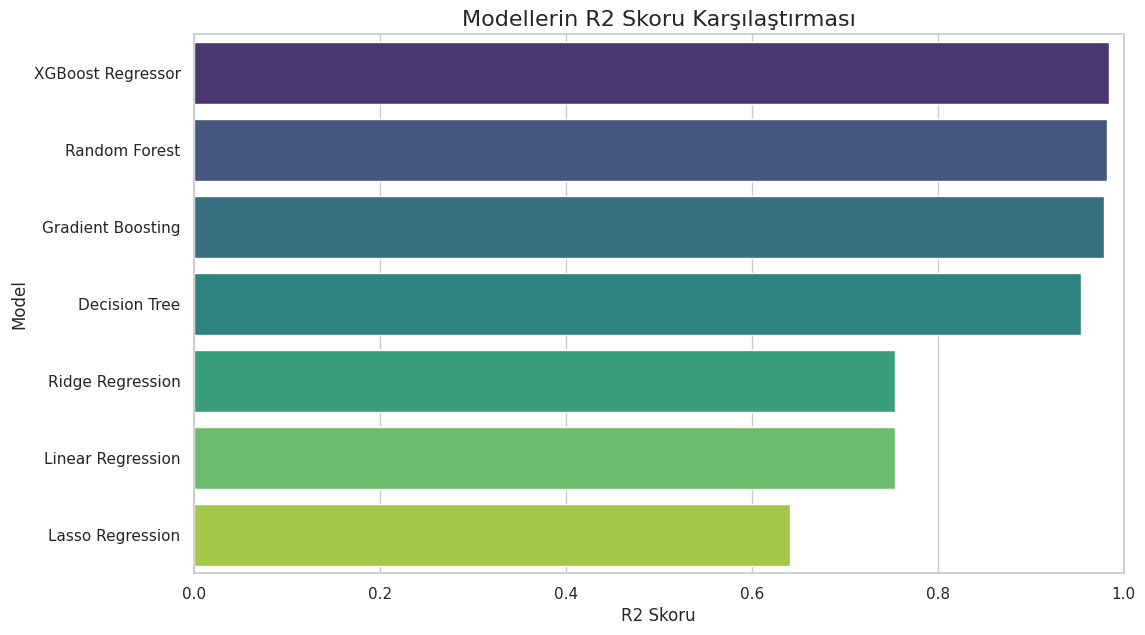

/tmp/ipykernel_7133/4011869006.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


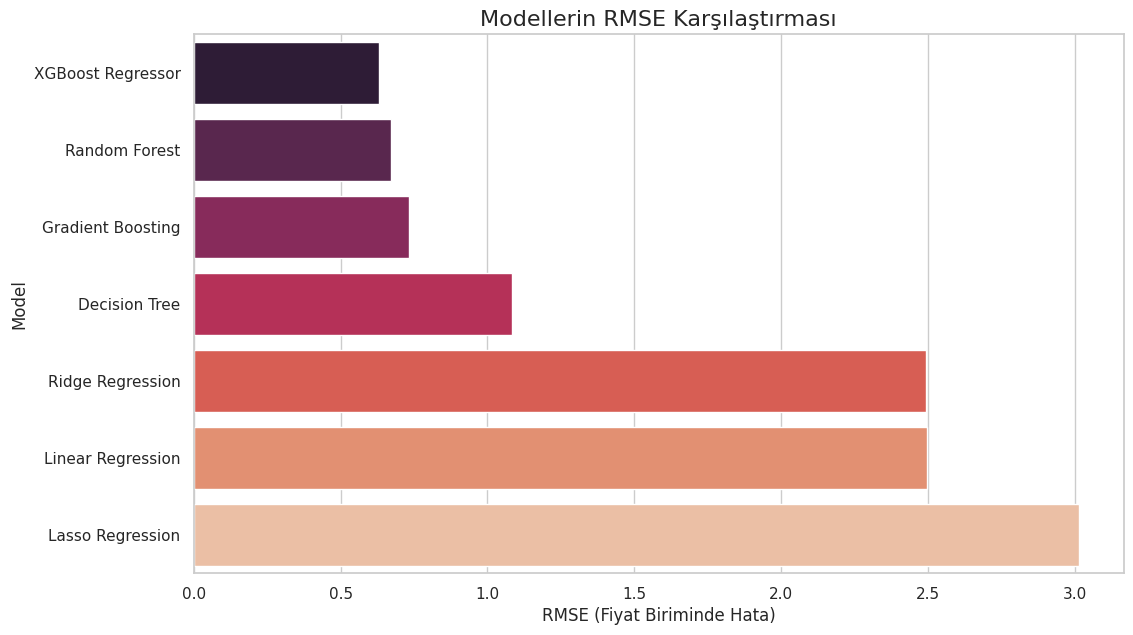

In [ ]:
# --- 1. Grafik: R2 Skoru Karşılaştırması (Yüksek olan daha iyi) ---

# Veriyi R2'ye göre büyükten küçüğe sırala
df_sorted_r2 = results_df.sort_values(by="R2 Skoru", ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(
    x="R2 Skoru",
    y="Model",
    data=df_sorted_r2,
    palette="viridis"
)
plt.title('Modellerin R2 Skoru Karşılaştırması', fontsize=16)
plt.xlabel('R2 Skoru', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.xlim(0, 1.0) # R2 skoru 0 ile 1 arasında olmalı
plt.show()

# --- 2. Grafik: RMSE Karşılaştırması (Düşük olan daha iyi) ---

# Veriyi RMSE'ye göre küçükten büyüğe sıralayalım
df_sorted_rmse = results_df.sort_values(by="RMSE (Kök Ort. Kare Hata)", ascending=True)

plt.figure(figsize=(12, 7))
sns.barplot(
    x="RMSE (Kök Ort. Kare Hata)",
    y="Model",
    data=df_sorted_rmse,
    palette="rocket"
)
plt.title('Modellerin RMSE Karşılaştırması', fontsize=16)
plt.xlabel('RMSE (Fiyat Biriminde Hata)', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.show()


--- En İyi Model (XGBoost Regressor) İçin Detaylı Analiz ---


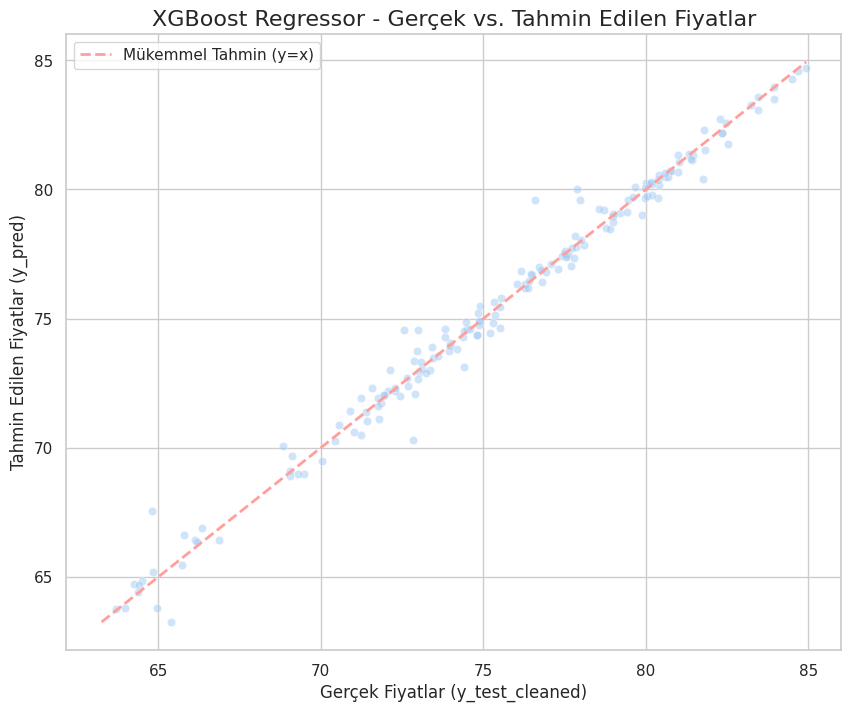

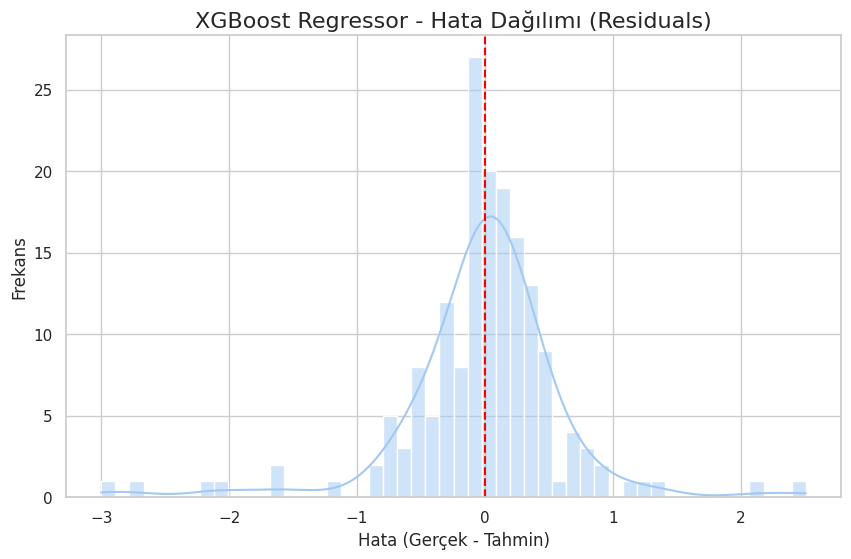

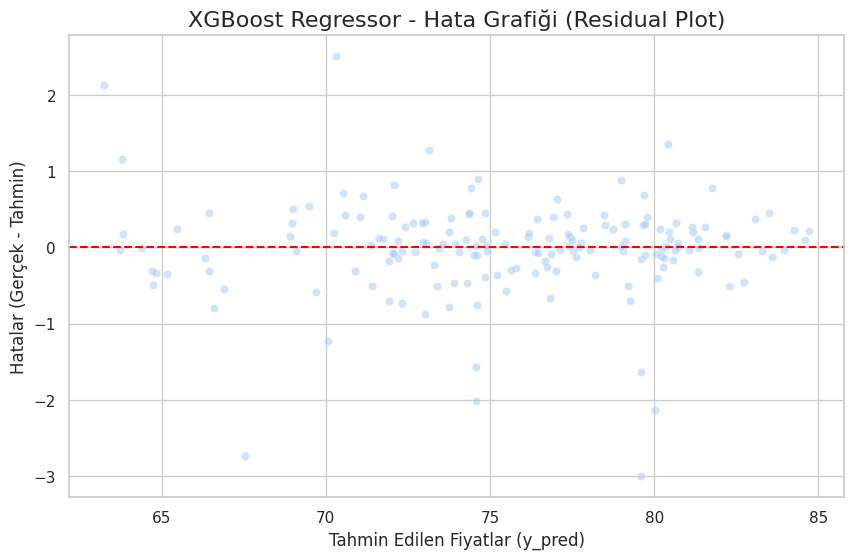

In [ ]:
# --- En İyi Modelin Detaylı Analizi ---

# 1. En iyi modeli 'results_df'den seç
best_model_name = results_df.iloc[0]["Model"]

# 2. 'models' sözlüğünden en iyi modelin eğitilmiş objesini al
best_model_object = models[best_model_name]

# 3. Bu modelle test verisi üzerinde tahminleri yap
y_pred_best = best_model_object.predict(X_test_scaled)

print(f"\n--- En İyi Model ({best_model_name}) İçin Detaylı Analiz ---")

# --- GRAFİK 2A: GERÇEK vs. TAHMİN EDİLEN (Scatter Plot) ---

plt.figure(figsize=(10, 8))
# y_test_cleaned (gerçek fiyatlar) ile y_pred_best (tahmini fiyatlar) karşılaştırılır.
sns.scatterplot(x=y_test_cleaned, y=y_pred_best, alpha=0.5)

# Mükemmel tahmin çizgisi (y=x) eklenir
max_val = max(y_test_cleaned.max(), y_pred_best.max())
min_val = min(y_test_cleaned.min(), y_pred_best.min())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Mükemmel Tahmin (y=x)')

plt.title(f'{best_model_name} - Gerçek vs. Tahmin Edilen Fiyatlar', fontsize=16)
plt.xlabel('Gerçek Fiyatlar (y_test_cleaned)', fontsize=12)
plt.ylabel('Tahmin Edilen Fiyatlar (y_pred)', fontsize=12)
plt.legend()
plt.show()

# --- GRAFİK 2B: HATA (RESIDUALS) DAĞILIMI (Histogram) ---
residuals = y_test_cleaned - y_pred_best

plt.figure(figsize=(10, 6))
sns.histplot(residuals, bins=50, kde=True)
plt.title(f'{best_model_name} - Hata Dağılımı (Residuals)', fontsize=16)
plt.xlabel('Hata (Gerçek - Tahmin)', fontsize=12)
plt.ylabel('Frekans', fontsize=12)
plt.axvline(x=0, color='red', linestyle='--') # Hatanın 0 olduğu yeri işaretle
plt.show()

# --- GRAFİK 2C: HATA (RESIDUALS) GRAFİĞİ (Scatter Plot) ---

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_best, y=residuals, alpha=0.5)
plt.title(f'{best_model_name} - Hata Grafiği (Residual Plot)', fontsize=16)
plt.xlabel('Tahmin Edilen Fiyatlar (y_pred)', fontsize=12)
plt.ylabel('Hatalar (Gerçek - Tahmin)', fontsize=12)
plt.axhline(y=0, color='red', linestyle='--') # 0 hata çizgisi
plt.show()

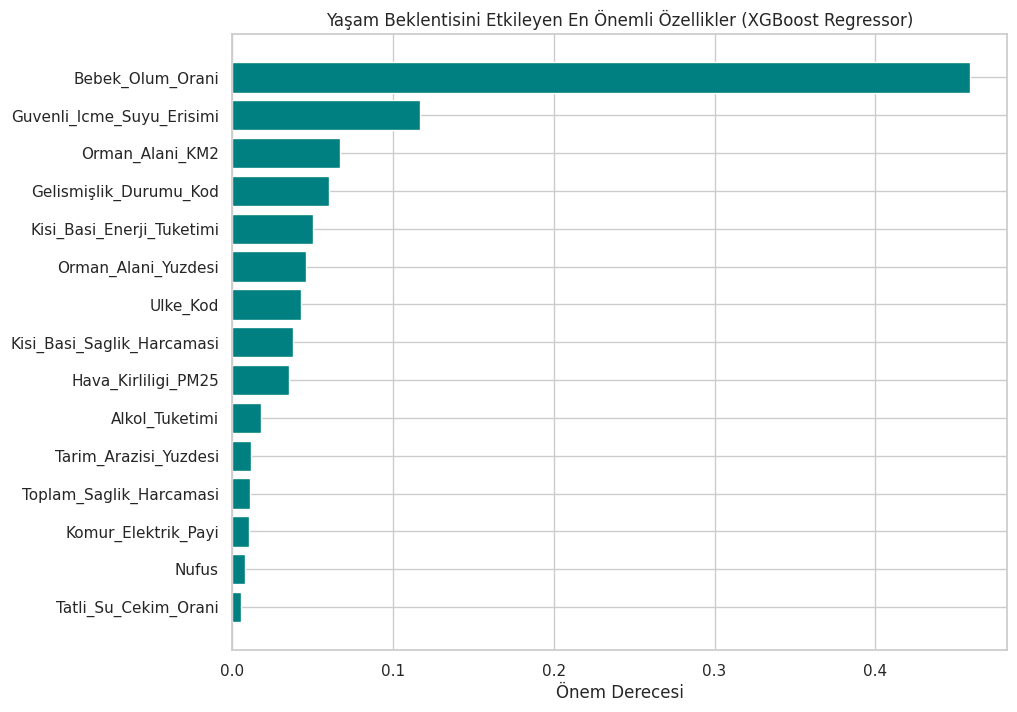

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Şampiyon modeli (Gradient Boosting) kullanarak özelliklerin önemini alalım
best_model = models["XGBoost Regressor"]
importances = best_model.feature_importances_
feature_names = X_train_cleaned.columns

# Önem sırasına göre dizelim
indices = np.argsort(importances)[-15:]  # En önemli 15 özelliği görelim

plt.figure(figsize=(10, 8))
plt.title('Yaşam Beklentisini Etkileyen En Önemli Özellikler (XGBoost Regressor)')
plt.barh(range(len(indices)), importances[indices], color='teal', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Önem Derecesi')
plt.show()

In [ ]:
def yasam_beklentisi_tahmin_et(ulke_adi, yil, kisi_basi_saglik_harcamasi,
                                guvenli_icme_suyu_erisimi, lise_okullasma_orani,
                                hava_kirliligi_pm25, bebek_olum_orani):

    # 1. Eğitimde kullanılan tüm sütunların şablonunu oluştur
    sablon_verisi = pd.DataFrame(0.0, index=[0], columns=X_train_cleaned.columns)

    # 2. Sayısal değerleri yerleştir
    sablon_verisi['Yil']                        = yil
    sablon_verisi['Kisi_Basi_Saglik_Harcamasi'] = kisi_basi_saglik_harcamasi
    sablon_verisi['Guvenli_Icme_Suyu_Erisimi']  = guvenli_icme_suyu_erisimi
    sablon_verisi['Lise_Okullasma_Orani']       = lise_okullasma_orani
    sablon_verisi['Hava_Kirliligi_PM25']        = hava_kirliligi_pm25
    sablon_verisi['Bebek_Olum_Orani']           = bebek_olum_orani

    # 3. Ordinal encoding (Gelismişlik_Durumu ve Kita)
    # Ülke adından otomatik olarak gelişmişlik ve kıta bilgisini çek
    if ulke_adi in df_analiz['Ulke_Adi'].values:
        ulke_satir = df_analiz[df_analiz['Ulke_Adi'] == ulke_adi].iloc[0]
        sablon_verisi['Gelismişlik_Durumu_Kod'] = ulke_satir['Gelismişlik_Durumu_Kod']
        sablon_verisi['Kita_Kod']               = ulke_satir['Kita_Kod']
        sablon_verisi['Ulke_Kod']               = ulke_satir['Ulke_Kod']
    else:
        print(f"⚠️ '{ulke_adi}' veri setinde bulunamadı, varsayılan değerler kullanılıyor.")

    # 4. Kalan sütunları ülkenin medyanıyla doldur
    for col in X_train_cleaned.columns:
        if sablon_verisi[col].values[0] == 0.0 and col not in [
            'Yil', 'Kisi_Basi_Saglik_Harcamasi', 'Guvenli_Icme_Suyu_Erisimi',
            'Lise_Okullasma_Orani', 'Hava_Kirliligi_PM25', 'Bebek_Olum_Orani',
            'Gelismişlik_Durumu_Kod', 'Kita_Kod', 'Ulke_Kod'
        ]:
            sablon_verisi[col] = X_train_cleaned[col].median()

    # 5. Ölçeklendirme
    sablon_scaled = scaler.transform(sablon_verisi)

    # 6. Tahmin
    tahmin = best_model.predict(sablon_scaled)[0]

    return tahmin


# --- TEST EDELİM ---
tahmin = yasam_beklentisi_tahmin_et(
    ulke_adi                  = 'Turkiye',
    yil                       = 2020,
    kisi_basi_saglik_harcamasi= 386.0,
    guvenli_icme_suyu_erisimi = 93.0,
    lise_okullasma_orani      = 112.5,
    hava_kirliligi_pm25       = 41.2,
    bebek_olum_orani          = 8.5
)

print("-" * 40)
print(f"🌍 YAŞAM BEKLENTİSİ TAHMİN SONUCU 🌍")
print(f"  Ülke : Turkiye")
print(f"  Yıl  : 2020")
print(f"  Tahmin Edilen Yaşam Beklentisi: {tahmin:.2f} yıl")
print("-" * 40)

----------------------------------------
🌍 YAŞAM BEKLENTİSİ TAHMİN SONUCU 🌍
  Ülke : Turkiye
  Yıl  : 2020
  Tahmin Edilen Yaşam Beklentisi: 73.26 yıl
----------------------------------------
